In [1]:
# nursing_grades 부분 EDA 실험 중

In [31]:
import sys

sys.path.append(r'C:\임시 폴더')

from jussam import load_data
# from helper204 import *
# from helper242 import *
from helper246 import *

간호대학 = load_data('nursing_grades')

📚 어느 간호학과 대학원에 지원한 학생들에 대한 합격/불합격 여부를 조사한 가상의 데이터(메타데이터 없음)


In [3]:
# 4 종 세트 확인

display(간호대학.head())
display(간호대학.shape)
display(간호대학.info())

,접수코드,이름,성별,필기점수,학부성적,병원경력,합격여부
0,NRS0001,장은우,남,380,3.610,3,불합격
1,NRS0002,최지호,남,660,3.670,3,합격
2,NRS0003,김하준,남,800,4.000,1,합격
3,NRS0004,임아윤,여,640,3.190,4,합격
4,NRS0005,강하준,남,520,2.930,4,불합격


(400, 7)

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   접수코드    400 non-null    str    
 1   이름      400 non-null    str    
 2   성별      400 non-null    str    
 3   필기점수    400 non-null    int64  
 4   학부성적    400 non-null    float64
 5   병원경력    400 non-null    int64  
 6   합격여부    400 non-null    str    
dtypes: float64(1), int64(2), str(4)
memory usage: 32.5 KB


None

In [4]:
# 이거까지 (도메인 개수) 확인

display(간호대학.nunique())

접수코드    400
이름      176
성별        2
필기점수     26
학부성적    132
병원경력      4
합격여부      3
dtype: int64

In [5]:
# 종속변수 / 명목형 변수 설정

종속변수 = '합격여부'
카테고리_대상_변수 = ['합격여부' , '병원경력' , '성별']

In [6]:
# 중복 및 결측치 확인

중복_및_결측치_확인완료 = my_EDA.결측치_중복_전처리(간호대학)

,결측치 개수,결측치 비율 (%)
접수코드,0,0.000
이름,0,0.000
성별,0,0.000
필기점수,0,0.000
학부성적,0,0.000
병원경력,0,0.000
합격여부,0,0.000


중복된 행의 수는 0
결측치 점검 및 중복 전처리 완료됨!!



In [7]:
# 명목형 변수에 맞추어 카테고리 임의 변환

카테고리_변환완료 = my_EDA.카테고리_임의_변환(중복_및_결측치_확인완료 , 카테고리_대상_변수)

# 'CHAS' 가 category 로 바뀜

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   접수코드    400 non-null    str     
 1   이름      400 non-null    str     
 2   성별      400 non-null    category
 3   필기점수    400 non-null    int64   
 4   학부성적    400 non-null    float64 
 5   병원경력    400 non-null    category
 6   합격여부    400 non-null    category
dtypes: category(3), float64(1), int64(1), str(2)
memory usage: 20.1 KB


None

In [8]:
기술통계량 , 명목형_기술통계량 , 카테고리_변환 , 명목형_변수 , 연속형_변수 = my_EDA.변수구분(카테고리_변환완료 , 종속변수)

# 수치형 변수 기술 통계량 확인
display(기술통계량.T)

,필기점수,학부성적
count,400.000,400.000
mean,587.700,3.390
std,115.517,0.381
min,220.000,2.260
25%,520.000,3.130
50%,580.000,3.395
75%,660.000,3.670
max,800.000,4.000
평균 중앙 차이,0.013,0.002
차이 결과,거의 비슷함,거의 비슷함


In [9]:
# 명목형 기술 통계량 확인
display(명목형_기술통계량.T)

,count,unique,top,freq
성별,400,2,여,206
병원경력,400,4,2,151
합격여부,400,3,불합격,250


In [10]:
# 카테고리 변환이 끝난 데이터 프레임 확인
# 임의 변환을 통해 거쳤지만 기존에 category 가 원래 있을 수 있기 때문에
# 이거 까지 한꺼번에 전부 변환

display(카테고리_변환.head())

,성별,병원경력,필기점수,학부성적,합격여부
0,남,3,380,3.610,불합격
1,남,3,660,3.670,합격
2,남,1,800,4.000,합격
3,여,4,640,3.190,합격
4,남,4,520,2.930,불합격


In [11]:
# 그럼 실제로 차이가 있나 확인

print('변수 구분 전 상태')

display(카테고리_변환완료.shape)

display(카테고리_변환완료.info())

변수 구분 전 상태


(400, 7)

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   접수코드    400 non-null    str     
 1   이름      400 non-null    str     
 2   성별      400 non-null    category
 3   필기점수    400 non-null    int64   
 4   학부성적    400 non-null    float64 
 5   병원경력    400 non-null    category
 6   합격여부    400 non-null    category
dtypes: category(3), float64(1), int64(1), str(2)
memory usage: 20.4 KB


None

In [12]:
print('변수 구분 후 상태')

display(카테고리_변환.shape)

display(카테고리_변환.info())

변수 구분 후 상태


(400, 5)

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   성별      400 non-null    category
 1   병원경력    400 non-null    category
 2   필기점수    400 non-null    int64   
 3   학부성적    400 non-null    float64 
 4   합격여부    400 non-null    category
dtypes: category(3), float64(1), int64(1)
memory usage: 7.9 KB


None

In [13]:
# 일단 칼럼 순서 빼고는 딱히 차이는 안 보이니 넘어간다
# 이제 구분 된 변수만 확인 한다

print(f'명목형 독립 변수 목록은 {명목형_변수}\n')
print(f'연속형 독립 변수 목록은 {연속형_변수}')

명목형 독립 변수 목록은 ['성별', '병원경력']

연속형 독립 변수 목록은 ['필기점수', '학부성적']


In [14]:
# 종속변수 타입 확인

display(카테고리_변환[종속변수].dtype.kind in ['i', 'u', 'f'])

display(카테고리_변환[종속변수].dtype == 'category')

# display(카테고리_변환[명목형_변수[0]].dtype == 'category')

False

True

y축 세우기 (단일 플롯)
그래프를 그렸습니다


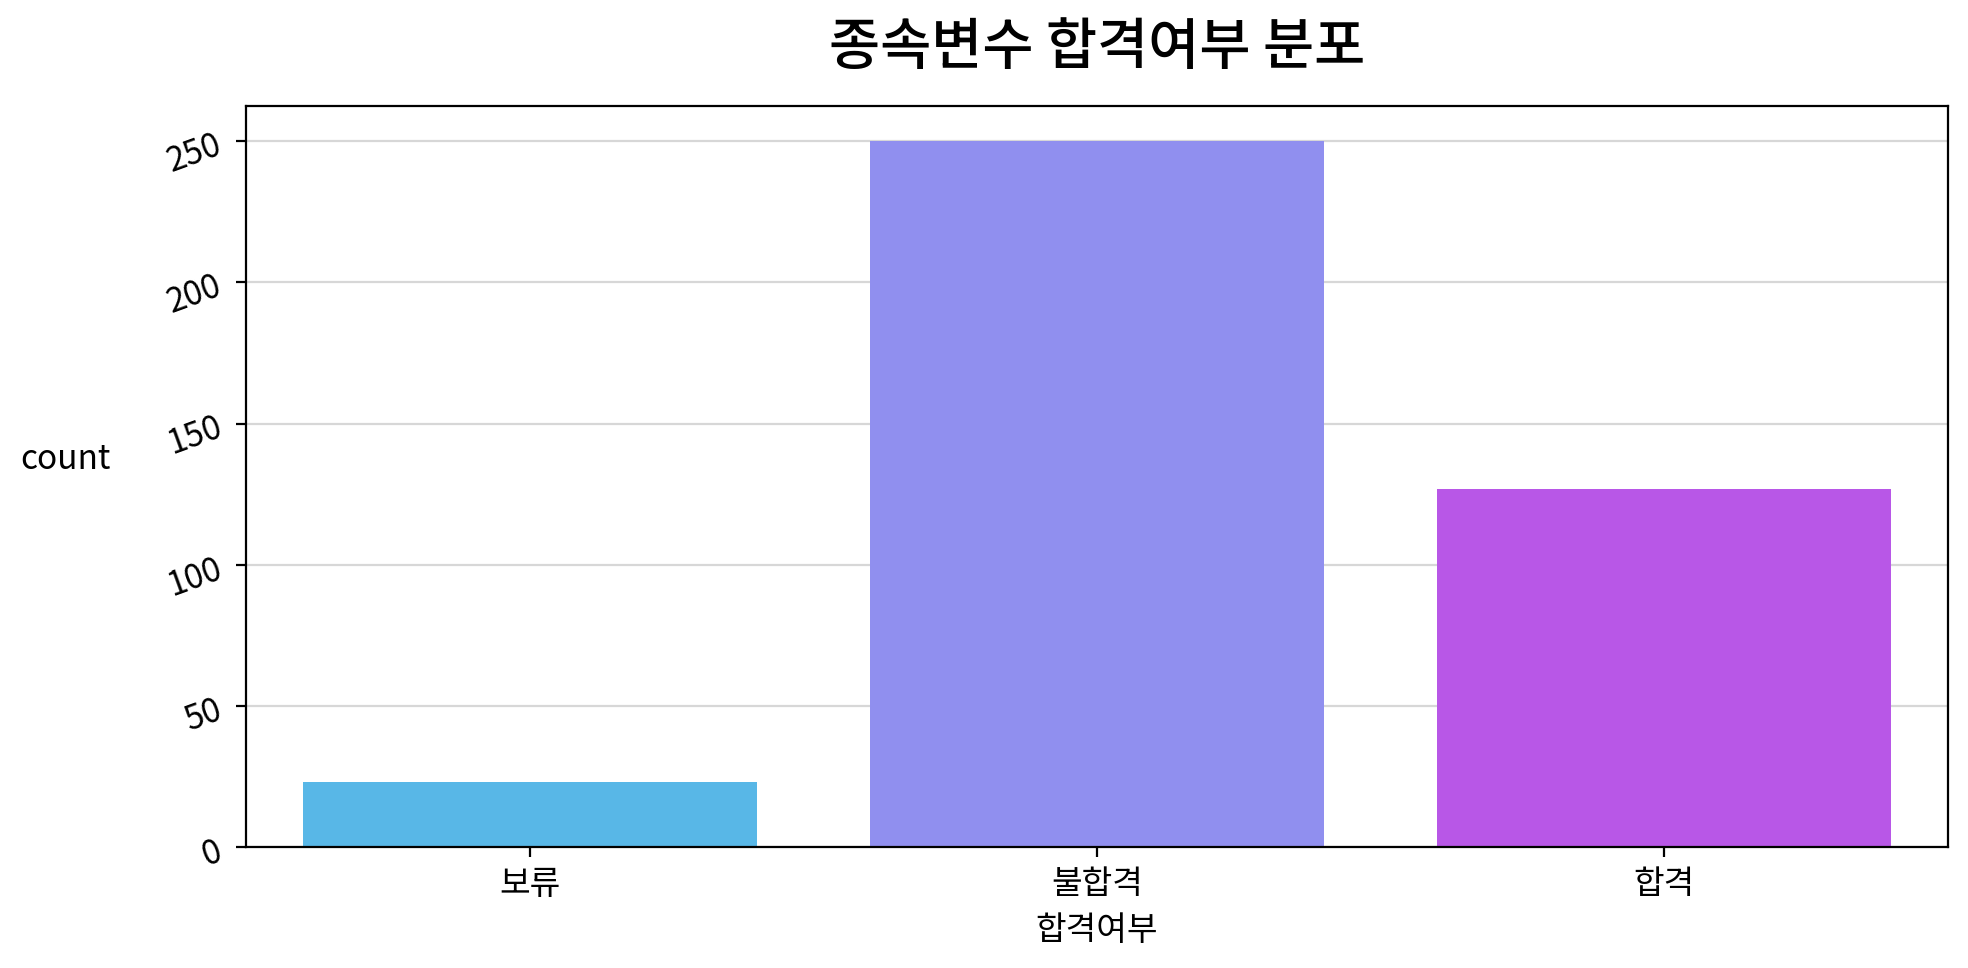

,빈도,비율
합격여부,,
불합격,250,0.625
합격,127,0.318
보류,23,0.058


,count,unique,top,freq
합격여부,400,3,불합격,250


,독립변수명,최소비율,불균형 여부
0,합격여부,0.058,True


In [15]:
# 종속변수 분포 확인

기술통계량_결과 , 결과 , _ = my_EDA.종속변수_분포_확인(카테고리_변환 = 카테고리_변환 , 종속변수 = 종속변수 , 표시옵션 = 0)

display(기술통계량_결과.T , 결과)

y축 세우기 (다중 플롯)
그래프를 그렸습니다


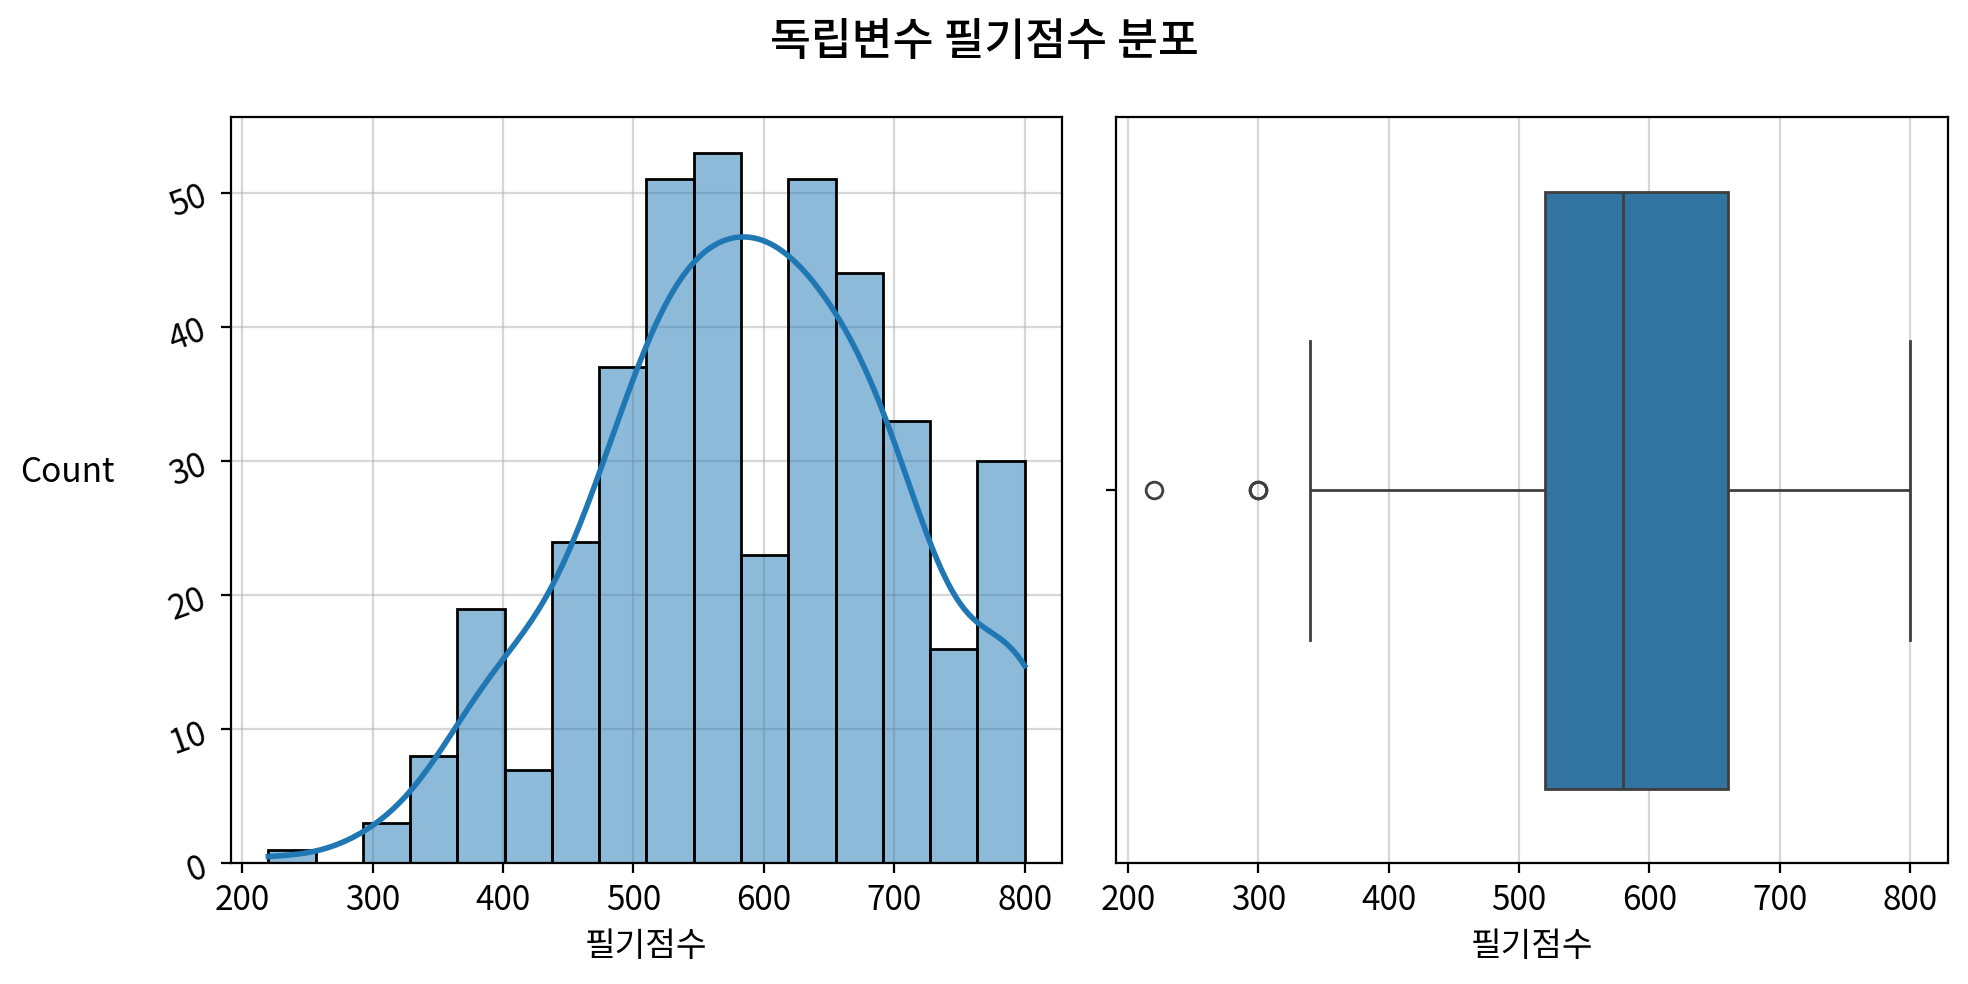

y축 세우기 (다중 플롯)
그래프를 그렸습니다


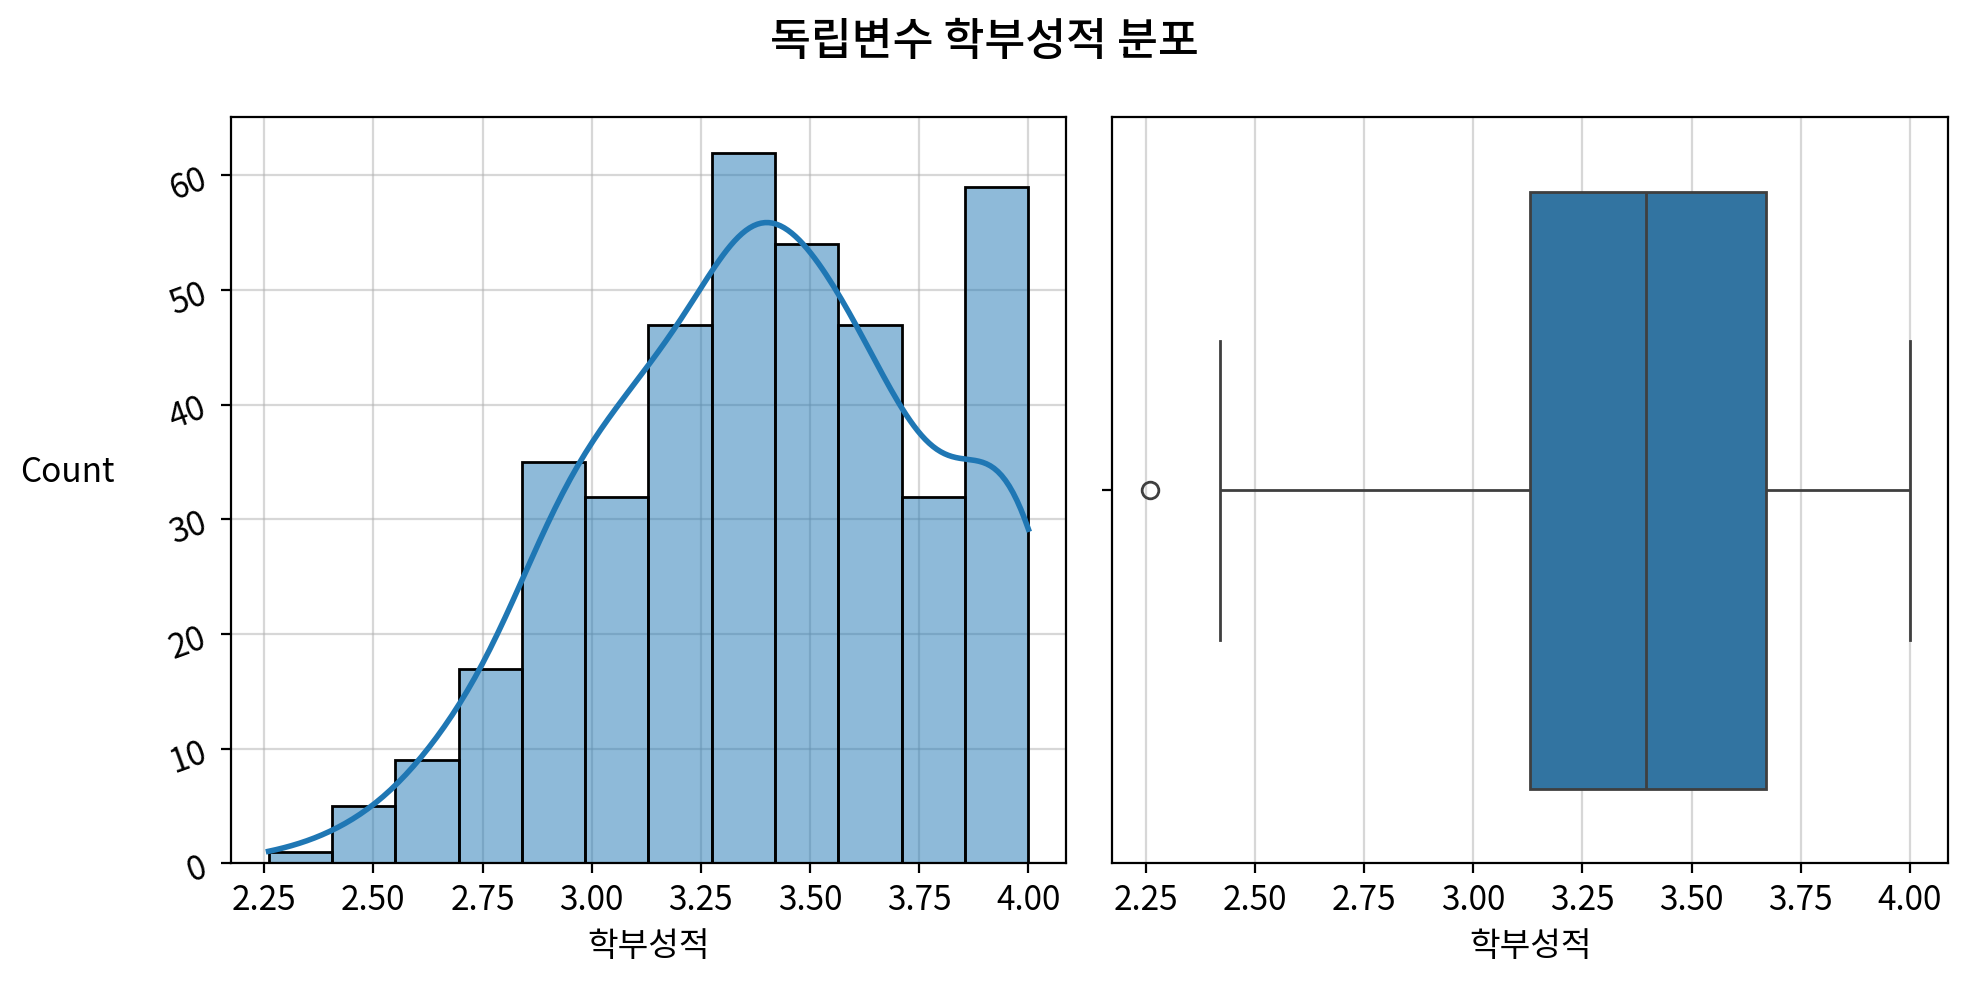

관찰 내용
독립변수명 점검 항목                               
필기점수  분포 모양 (왜도)  -0.14 이므로 좌편향 (왼쪽으로 치우침)
      봉우리 수                            1 개
      이상치                            1.0 %
      가장 많이 분포          584.279 에 가장 많이 분포
      로그 변환 진단결과                      none
      실제 진단결과                 이상치만 점검 후 진행
학부성적  분포 모양 (왜도)  -0.21 이므로 좌편향 (왼쪽으로 치우침)
      봉우리 수                            1 개
      이상치                           0.25 %
      가장 많이 분포            3.401 에 가장 많이 분포
      로그 변환 진단결과                      none
      실제 진단결과                 이상치만 점검 후 진행

In [16]:
# 독립변수 대표로 2개만 연속형 단변량 분석

연속형_단변량_결과확인 = my_EDA.독립변수_연속형_단변량_분석(카테고리_변환 = 카테고리_변환 , 연속형_변수 = 연속형_변수[:3] , 표시옵션 = False)

display(연속형_단변량_결과확인)

y축 세우기 (단일 플롯)
그래프를 그렸습니다


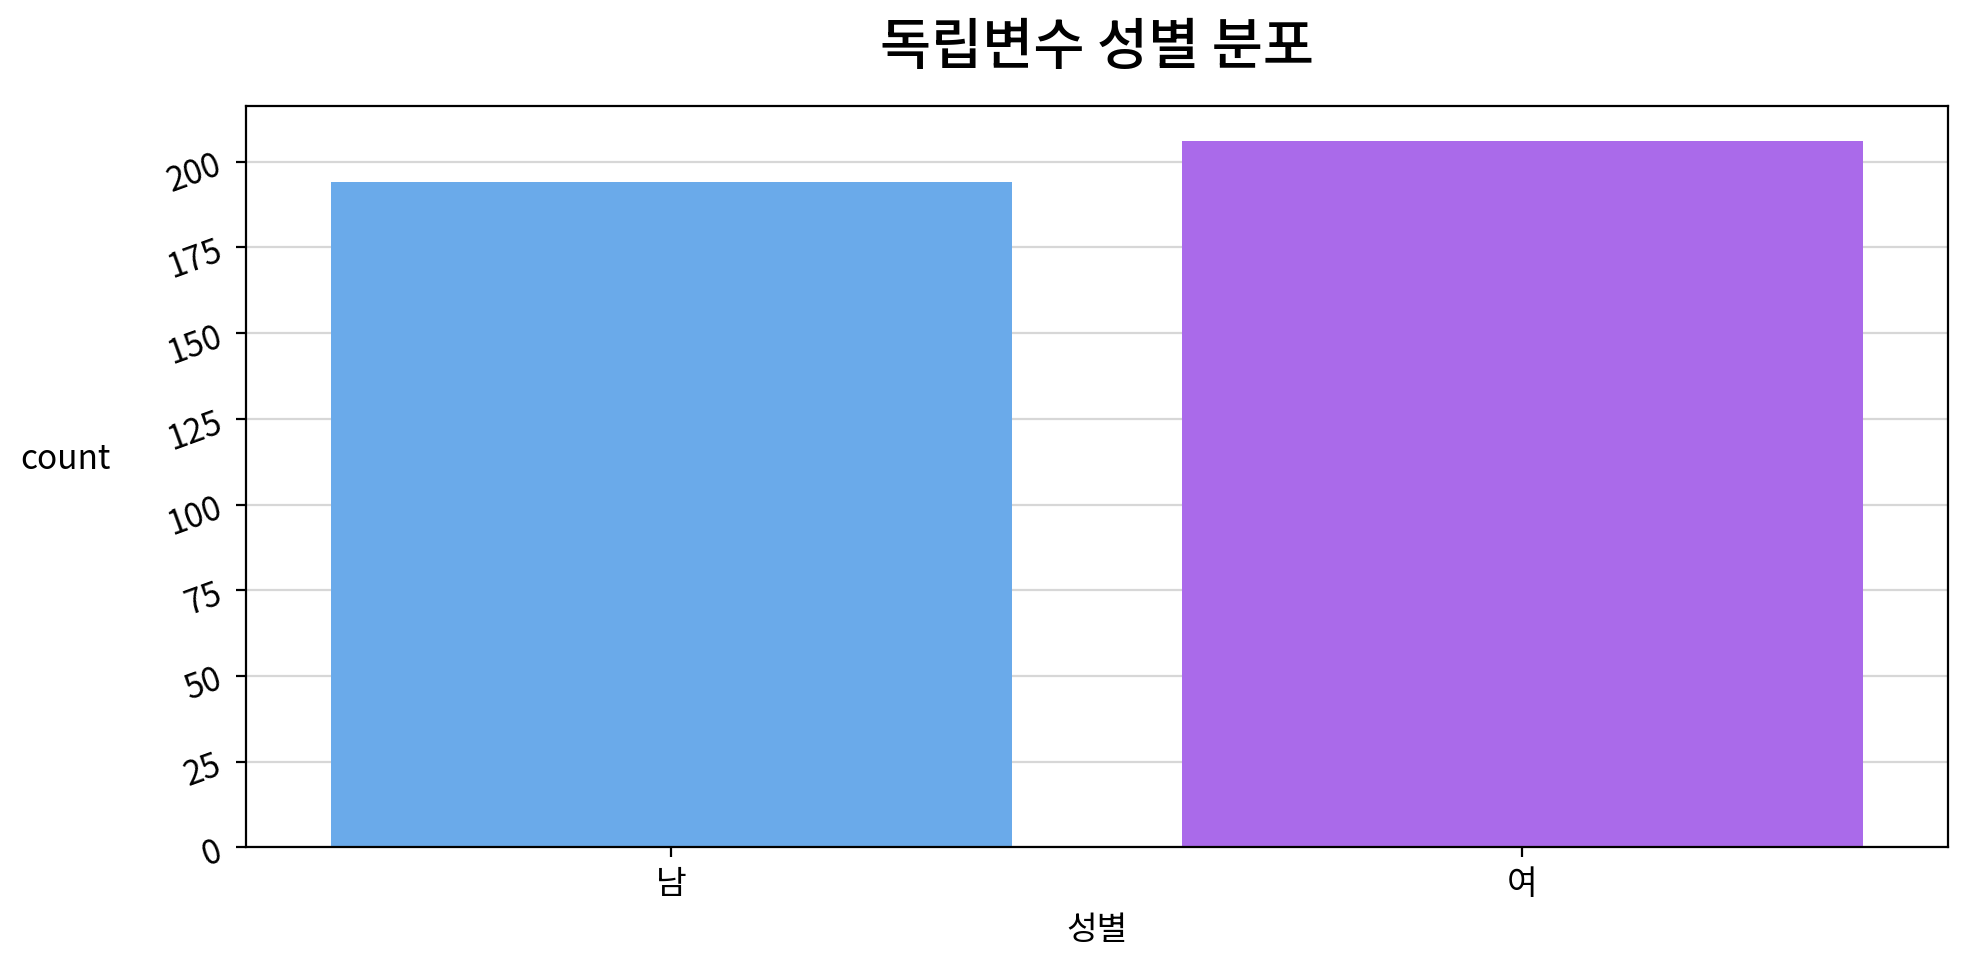

,빈도,비율
성별,,
여,206,0.515
남,194,0.485


y축 세우기 (단일 플롯)
그래프를 그렸습니다


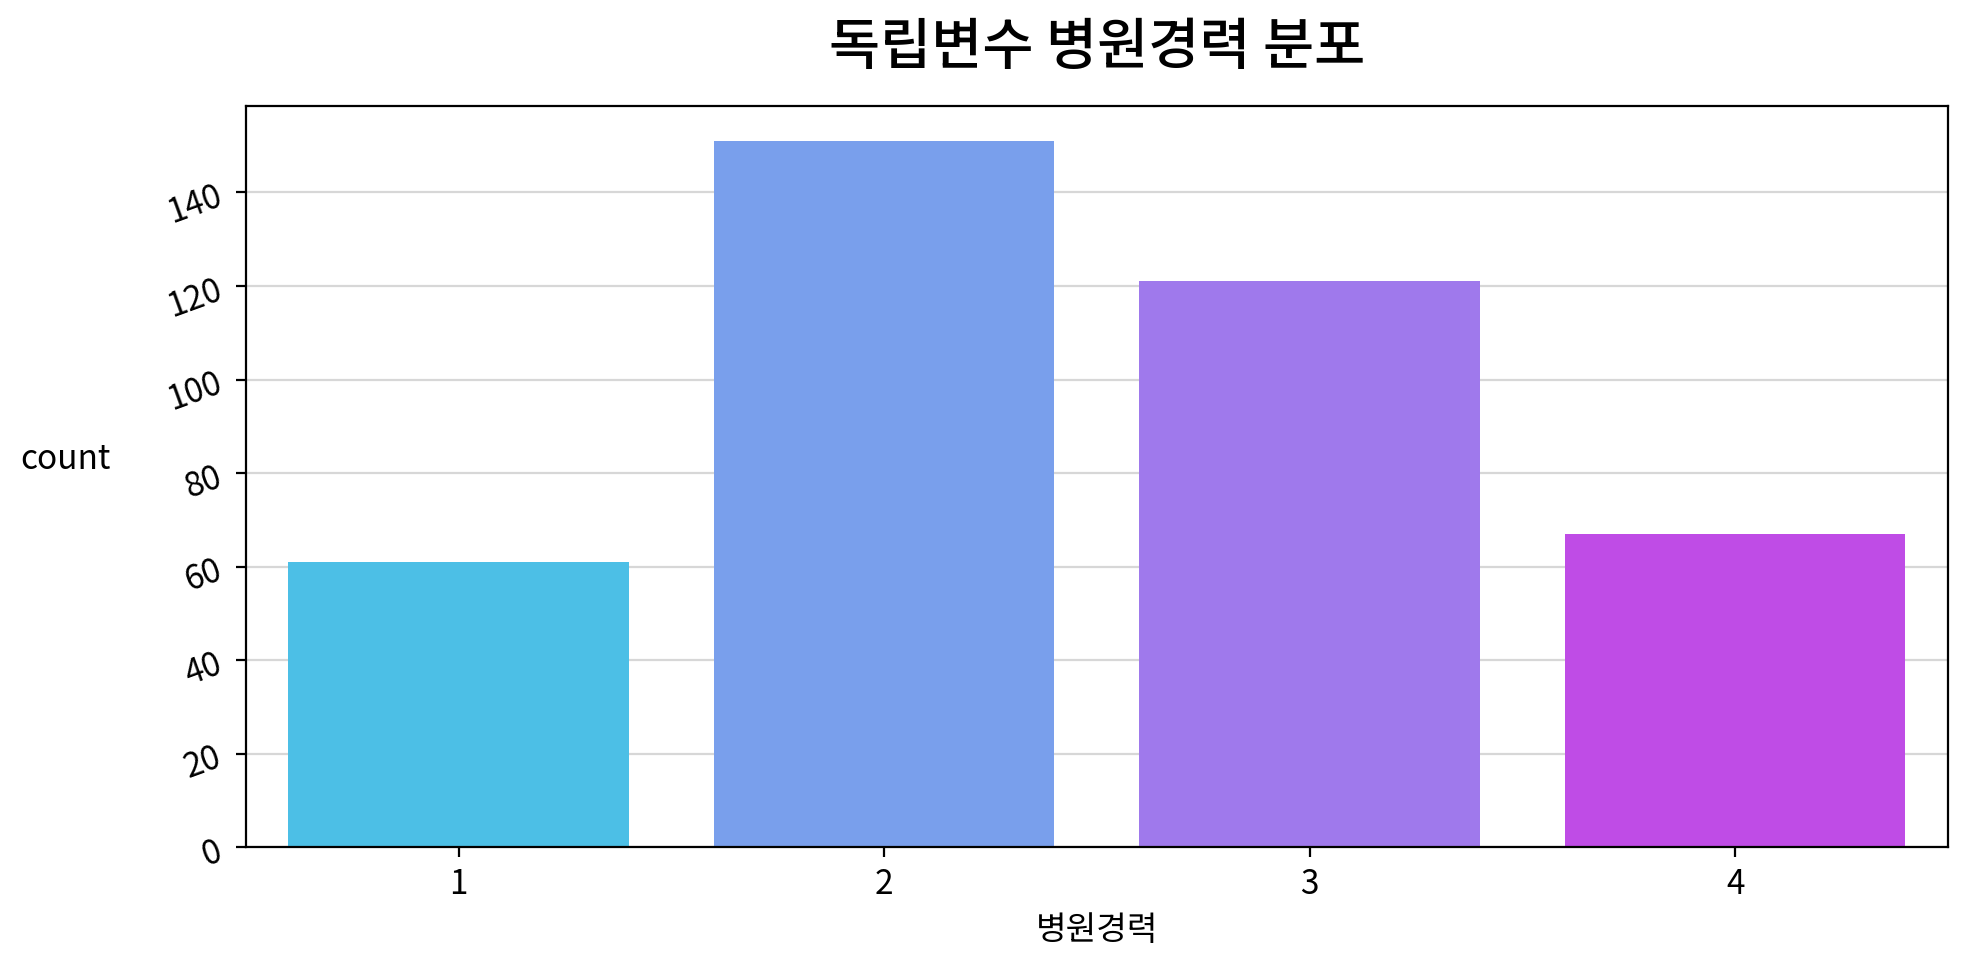

,빈도,비율
병원경력,,
2,151,0.378
3,121,0.302
4,67,0.168
1,61,0.152


(  독립변수명  최소비율  불균형 여부
 0    성별 0.485   False
 0  병원경력 0.152    True,
        빈도    비율
 병원경력           
 2     151 0.378
 3     121 0.302
 4      67 0.168
 1      61 0.152)

In [17]:
# 독립변수 명목형 단변량 분석

명목형_단변량_결과확인 = my_EDA.독립변수_명목형_단변량_분석(카테고리_변환 = 카테고리_변환 , 명목형_변수 = 명목형_변수 , 
                      표시옵션 = 0)

display(명목형_단변량_결과확인)

In [18]:
print(카테고리_변환[연속형_변수].head())

   필기점수  학부성적
0   380 3.610
1   660 3.670
2   800 4.000
3   640 3.190
4   520 2.930


In [19]:
카테고리_변환[종속변수].dtype == 'category'

True

In [20]:
# 독립변수 연속형 대표 2 개만 상관분석
# 종속변수가 명목형 변수면 차단 시켜야함

연속형_상관분석_결과확인 = my_EDA.독립변수_연속형_상관분석(카테고리_변환 = 카테고리_변환 , 연속형_변수 = 연속형_변수[:2] , 종속변수 = 종속변수 ,
                     표시옵션 = 0)

종속변수가 명목형 변수이기 때문에 상관분석 생략!!


In [33]:
# 두 개의 고유값 차이 분석 (t 검정 과정)

t검정_결과확인 = my_EDA.두_개의_고유값_분석(카테고리_변환 , 종속변수 , 표시옵션 = 0)

display(t검정_결과확인)

t 검정 대상이 없습니다


None

#### 필기점수 -> 합격여부

,검정방식,Source,ddof1,ddof2,F,p_unc,np2,효과크기
0,ANOVA,합격여부,2,397,7.778,0.000,0.038,작음


y축 세우기 (단일 플롯)
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

보류 vs. 불합격: Custom statistical test, P_val:4.339e-01
불합격 vs. 합격: Custom statistical test, P_val:1.585e-03
보류 vs. 합격: Custom statistical test, P_val:1.230e-02
그래프를 그렸습니다


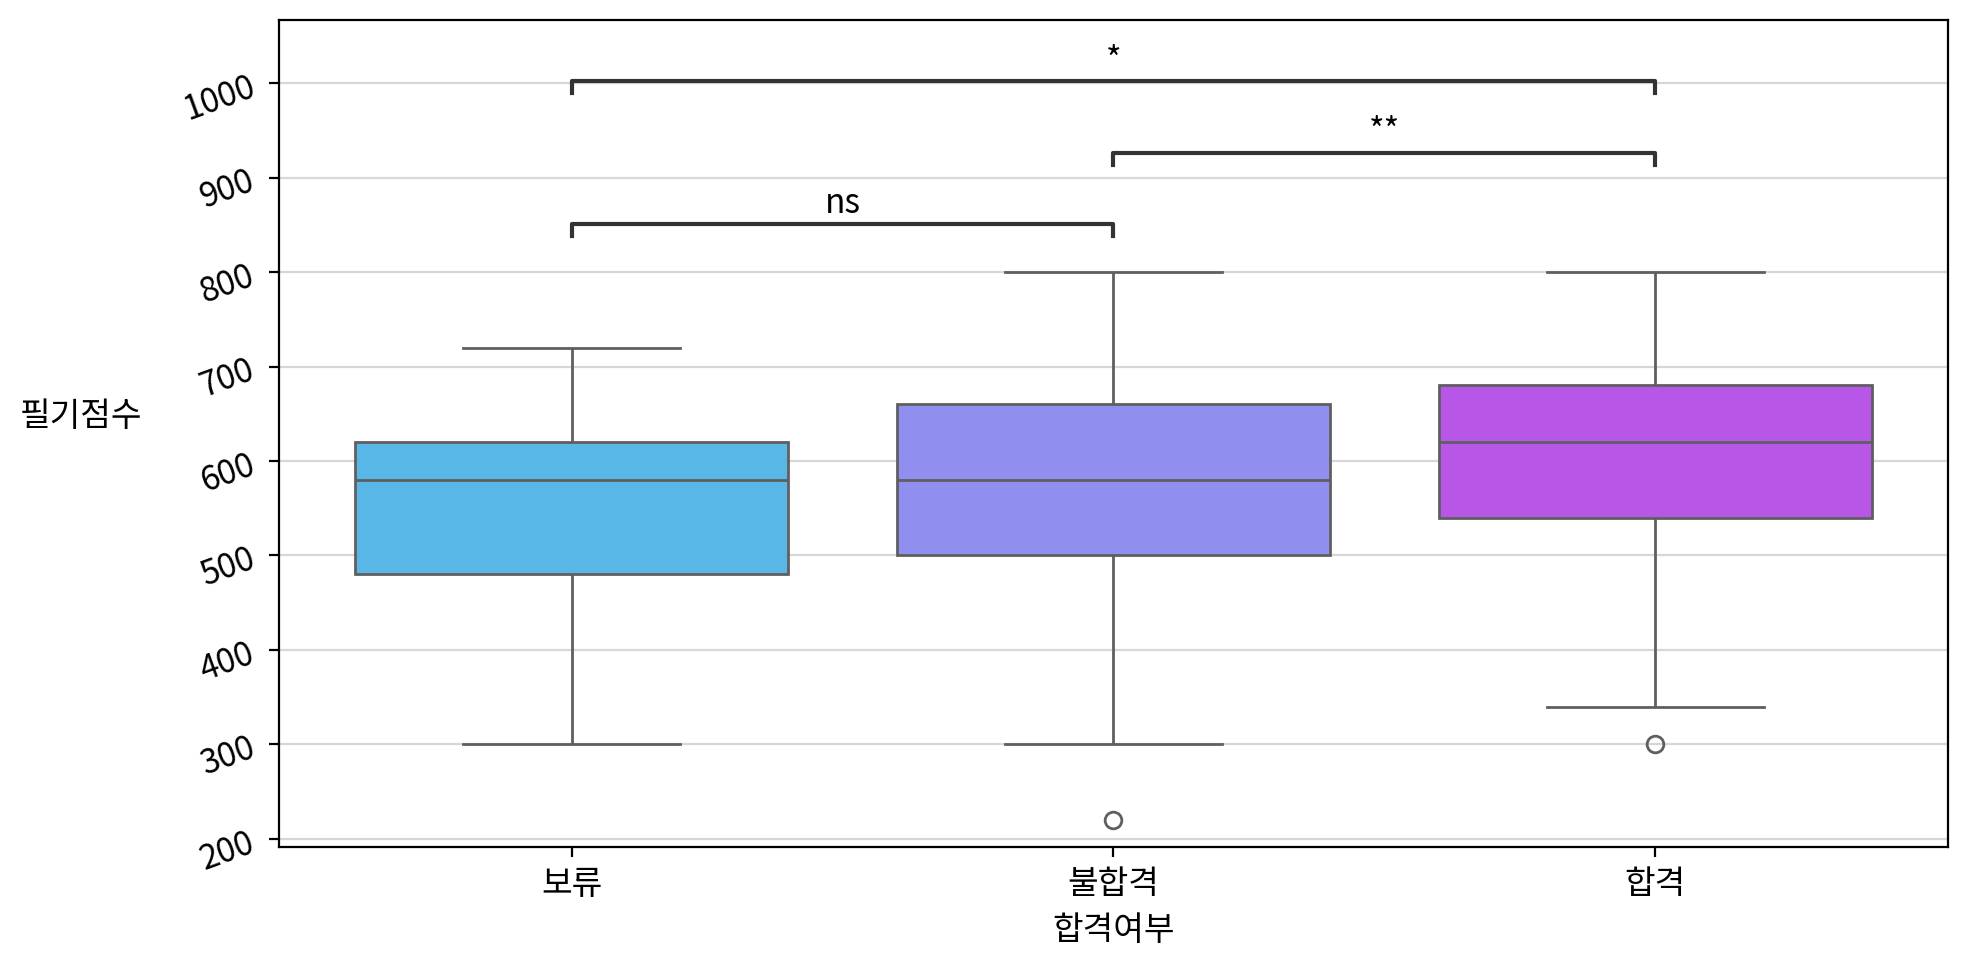

,검정방식,A,B,mean_A,mean_B,diff,se,T,p_tukey,hedges,귀무가설 기각 여부,유의미한 차이 여부,효과 크기
0,Tukey HSD,보류,불합격,545.217,575.760,-30.543,24.753,-1.234,0.434,-0.263,False,False,작음
1,Tukey HSD,보류,합격,545.217,618.898,-73.680,25.744,-2.862,0.012,-0.664,True,True,중간
2,Tukey HSD,불합격,합격,575.760,618.898,-43.138,12.379,-3.485,0.002,-0.380,True,True,작음


#### 학부성적 -> 합격여부

,검정방식,Source,ddof1,ddof2,F,p_unc,np2,효과크기
0,ANOVA,합격여부,2,397,7.423,0.001,0.036,작음


y축 세우기 (단일 플롯)
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

보류 vs. 불합격: Custom statistical test, P_val:3.798e-01
불합격 vs. 합격: Custom statistical test, P_val:5.119e-04
보류 vs. 합격: Custom statistical test, P_val:8.496e-01
그래프를 그렸습니다


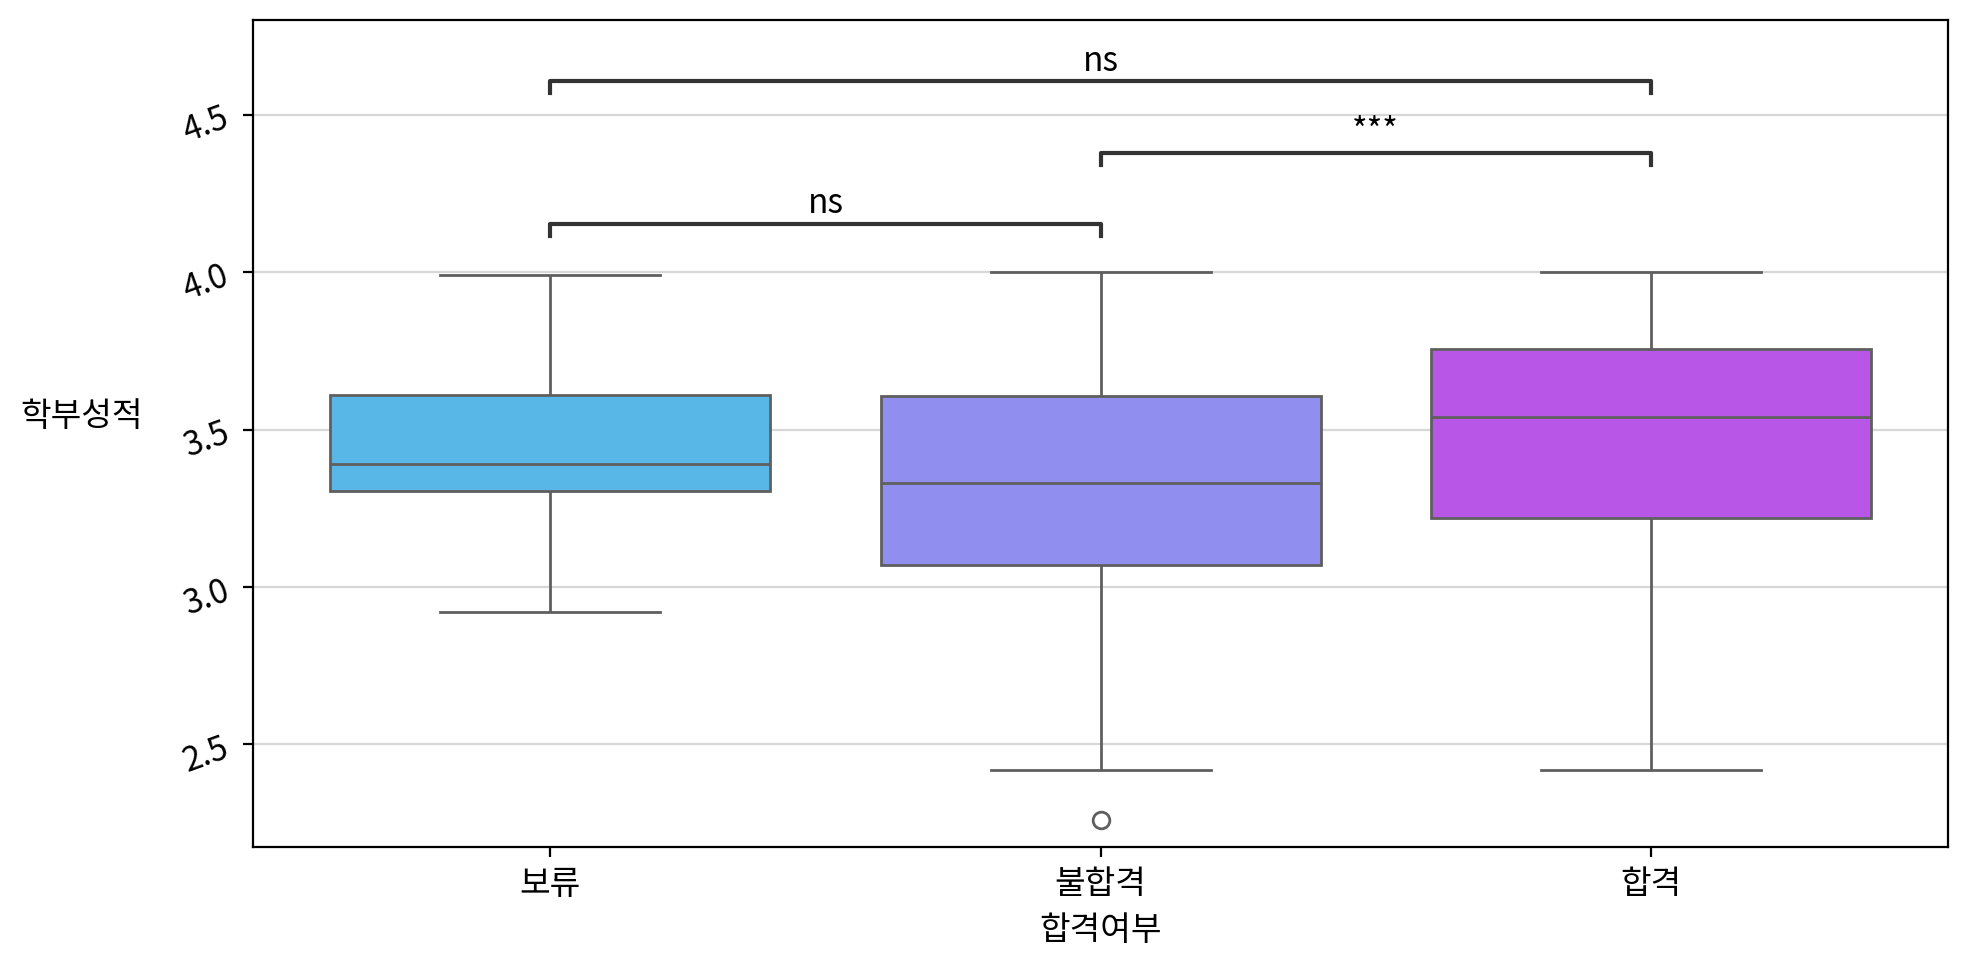

,검정방식,A,B,mean_A,mean_B,diff,se,T,p_tukey,hedges,귀무가설 기각 여부,유의미한 차이 여부,효과 크기
0,Tukey HSD,보류,불합격,3.443,3.335,0.108,0.082,1.329,0.380,0.287,False,False,작음
1,Tukey HSD,보류,합격,3.443,3.489,-0.046,0.085,-0.544,0.850,-0.128,False,False,거의 없음
2,Tukey HSD,불합격,합격,3.335,3.489,-0.155,0.041,-3.789,0.001,-0.407,True,True,작음


In [22]:
# 여러 개의 고유값 차이 분석 (ANOVA 과정)

아노바_결과확인 , 아노바_사후결과확인 = my_EDA.여러_개의_고유값_분석(카테고리_변환 = 카테고리_변환 , 종속변수 = 종속변수 , palette = 'cool' , 표시옵션 = 1)

In [23]:
아노바_결과확인

,독립변수,종속변수,집단 차이 여부,p_unc,효과크기
0,필기점수,합격여부,True,0.000,작음
1,학부성적,합격여부,True,0.001,작음


In [24]:
아노바_사후결과확인

,독립변수,종속변수,A,B,유의미한 차이 여부,효과 크기
0,필기점수,합격여부,보류,합격,True,중간
1,필기점수,합격여부,불합격,합격,True,작음
2,학부성적,합격여부,불합격,합격,True,작음


In [25]:
다중상관분석_결과 , 신호감지결과 = my_EDA.다중공산성_탐지(카테고리_변환 = 카테고리_변환 , 연속형_변수 = 연속형_변수 , 표시옵션 = 0)

display(다중상관분석_결과)

display(신호감지결과)

,필기점수,학부성적
필기점수,1.000,0.383
학부성적,0.383,1.000


,,검정방법,상관계수,p값,강도결과,유의미한 차이 여부,X 정규성,Y 정규성,선형 여부,이상치 여부,왜도 여부
x,y,,,,,,,,,,
필기점수,학부성적,스피어만 (Spearman),0.383,0.000,보통,True,True,False,True,False,False


,최대 y,최대 상관계수,개수,columns,진단결과
x,,,,,
필기점수,학부성적,0.383,0,-,양호
학부성적,필기점수,0.383,0,-,양호


#### 합격여부

y축 세우기 (단일 플롯)
기본은 평균 값을 구하게 됩니다
그래프를 그렸습니다


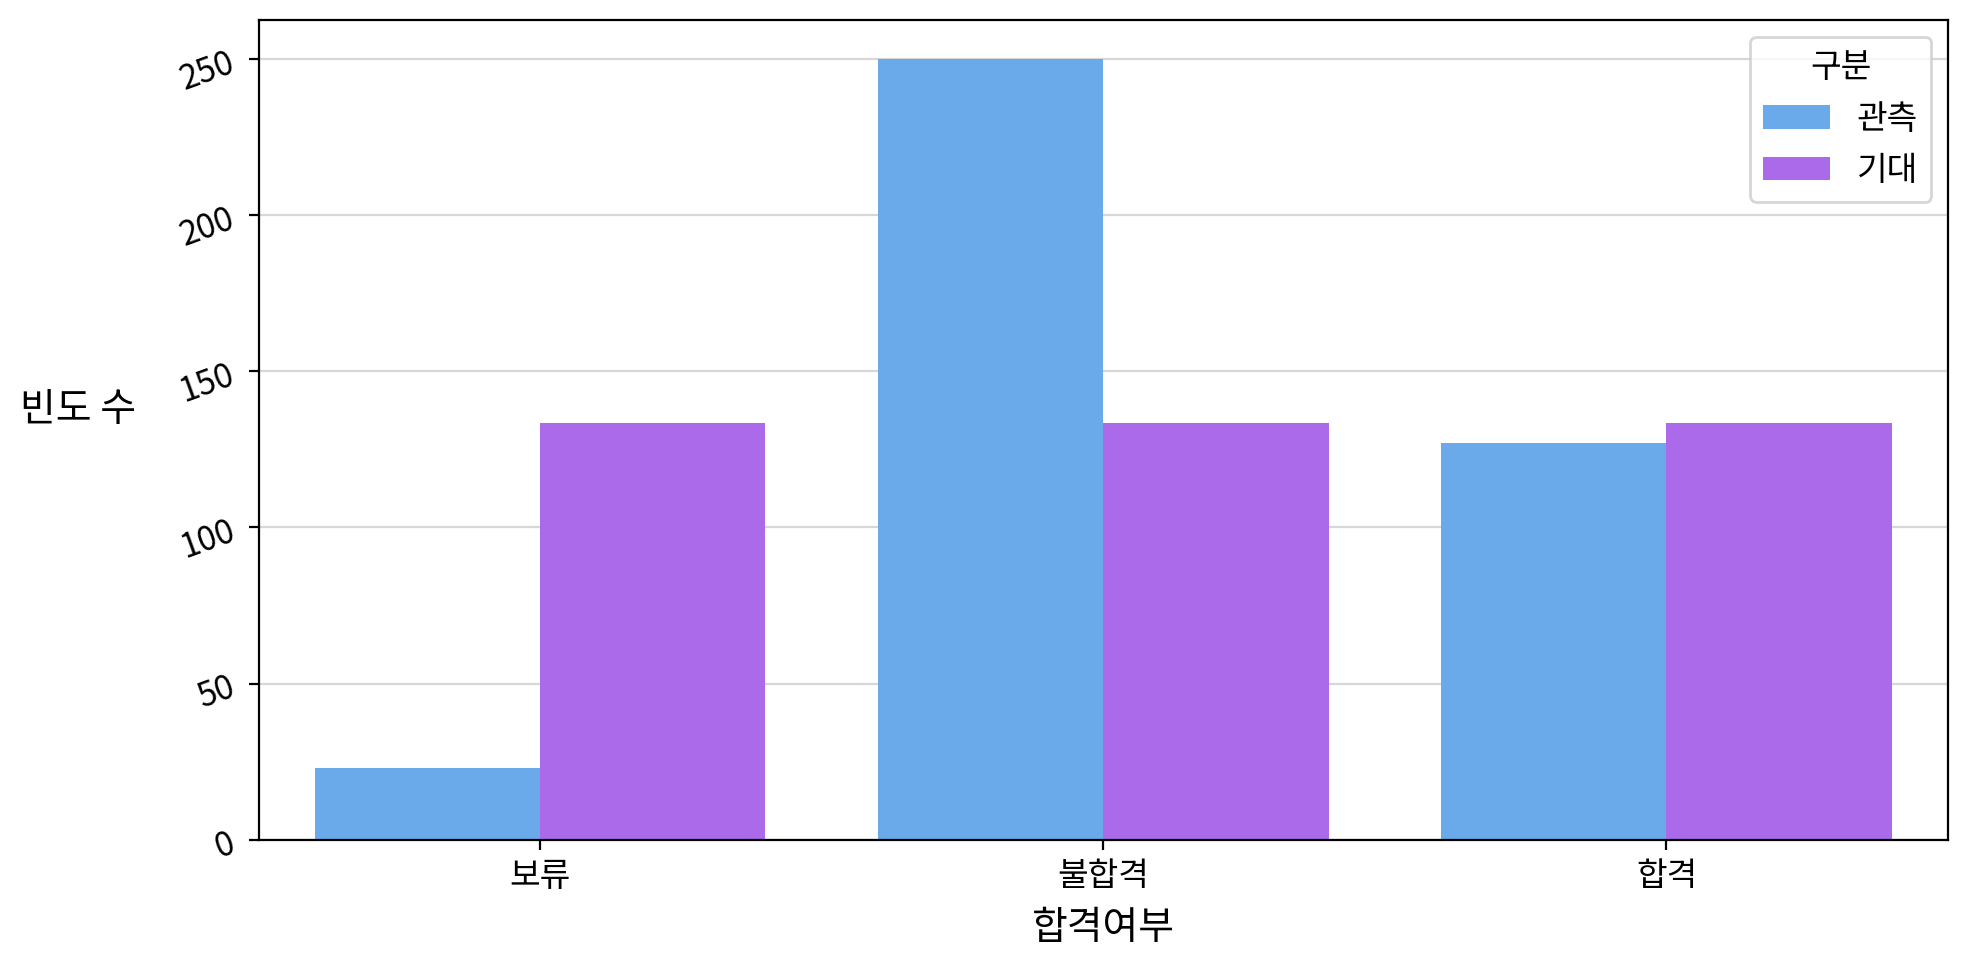

,통계량,자유도,p 값,귀무가설 기각 여부,유의미한 차이 여부,효과 크기,효과 크기 (설명),기대값 최소,가정 확인,검정 방식
카이제곱 적합도 검정,193.685,2,0.000,True,True,0.696,강함,133.330,True,카이제곱 적합도 검정


#### 성별 -> 합격여부

y축 세우기 (단일 플롯)
합계를 기준으로 피벗 테이블이 만들어지고 요약 될 예정
색상이 채워집니다
그래프를 그렸습니다


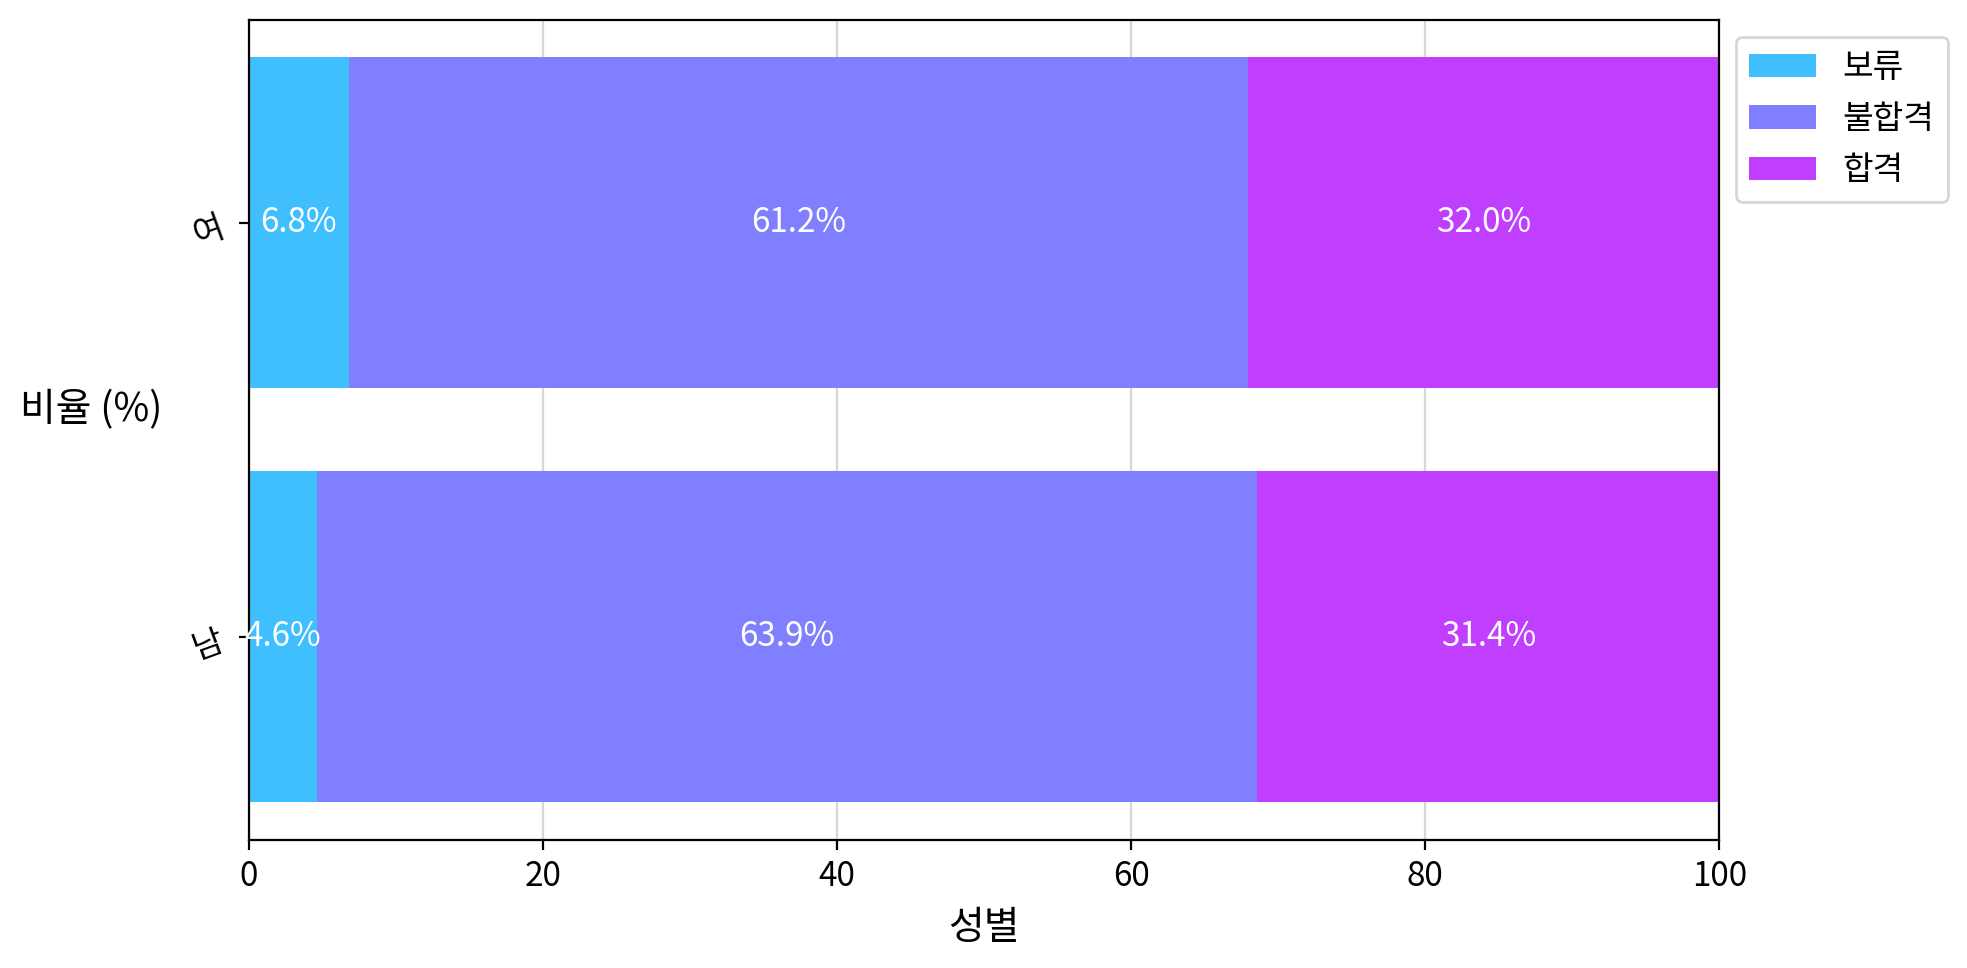

,,검정 방식,통계량 결과,자유도 결과,p값 결과,귀무가설 기각 여부,유의미한 차이 여부,효과 크기,효과 크기 (설명),기대값 최소,가설 검정 만족 여부
행,열,,,,,,,,,,
성별,합격여부,카이제곱 테스트 of homogeneity,0.941,2,0.625,False,False,0.049,거의 없음,11.150,True


합격여부,보류,불합격,합격,전체 합계 (개수)
성별,,,,
남,0.046,0.639,0.314,194
여,0.068,0.612,0.320,206


y축 세우기 (단일 플롯)
그래프를 그렸습니다


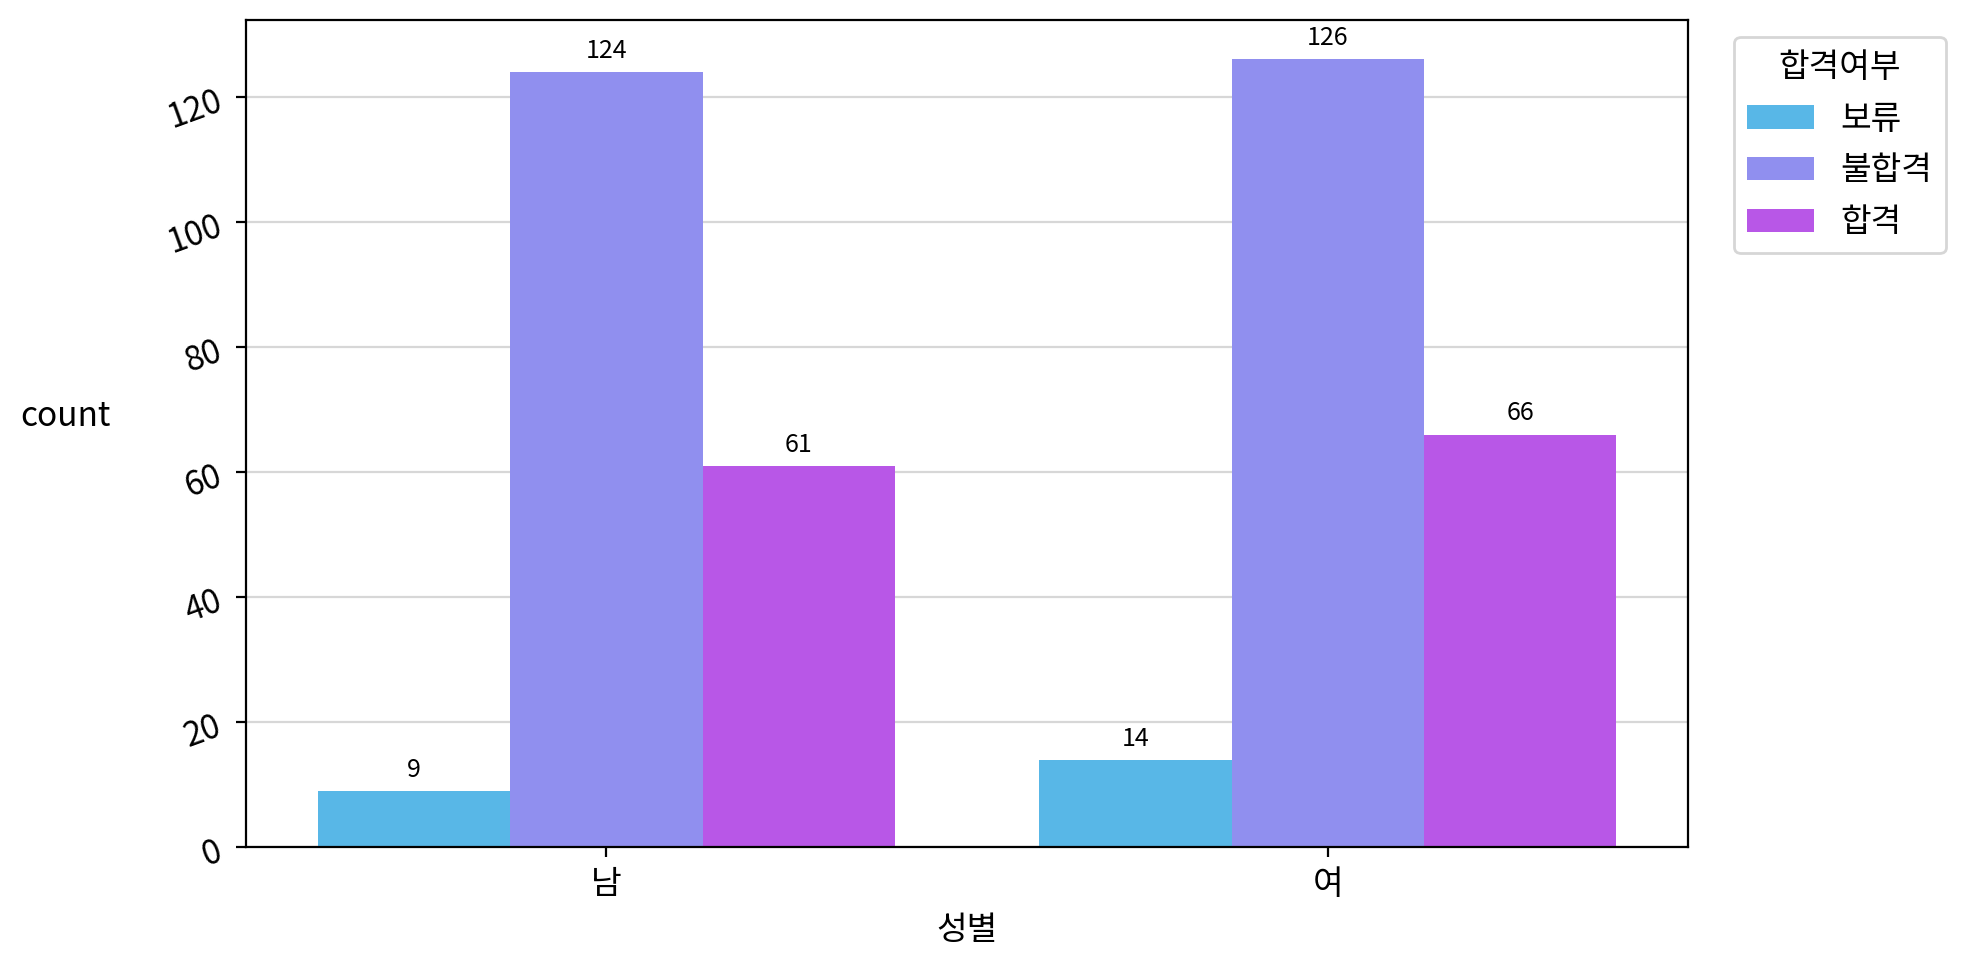

#### 병원경력 -> 합격여부

y축 세우기 (단일 플롯)
합계를 기준으로 피벗 테이블이 만들어지고 요약 될 예정
색상이 채워집니다
그래프를 그렸습니다


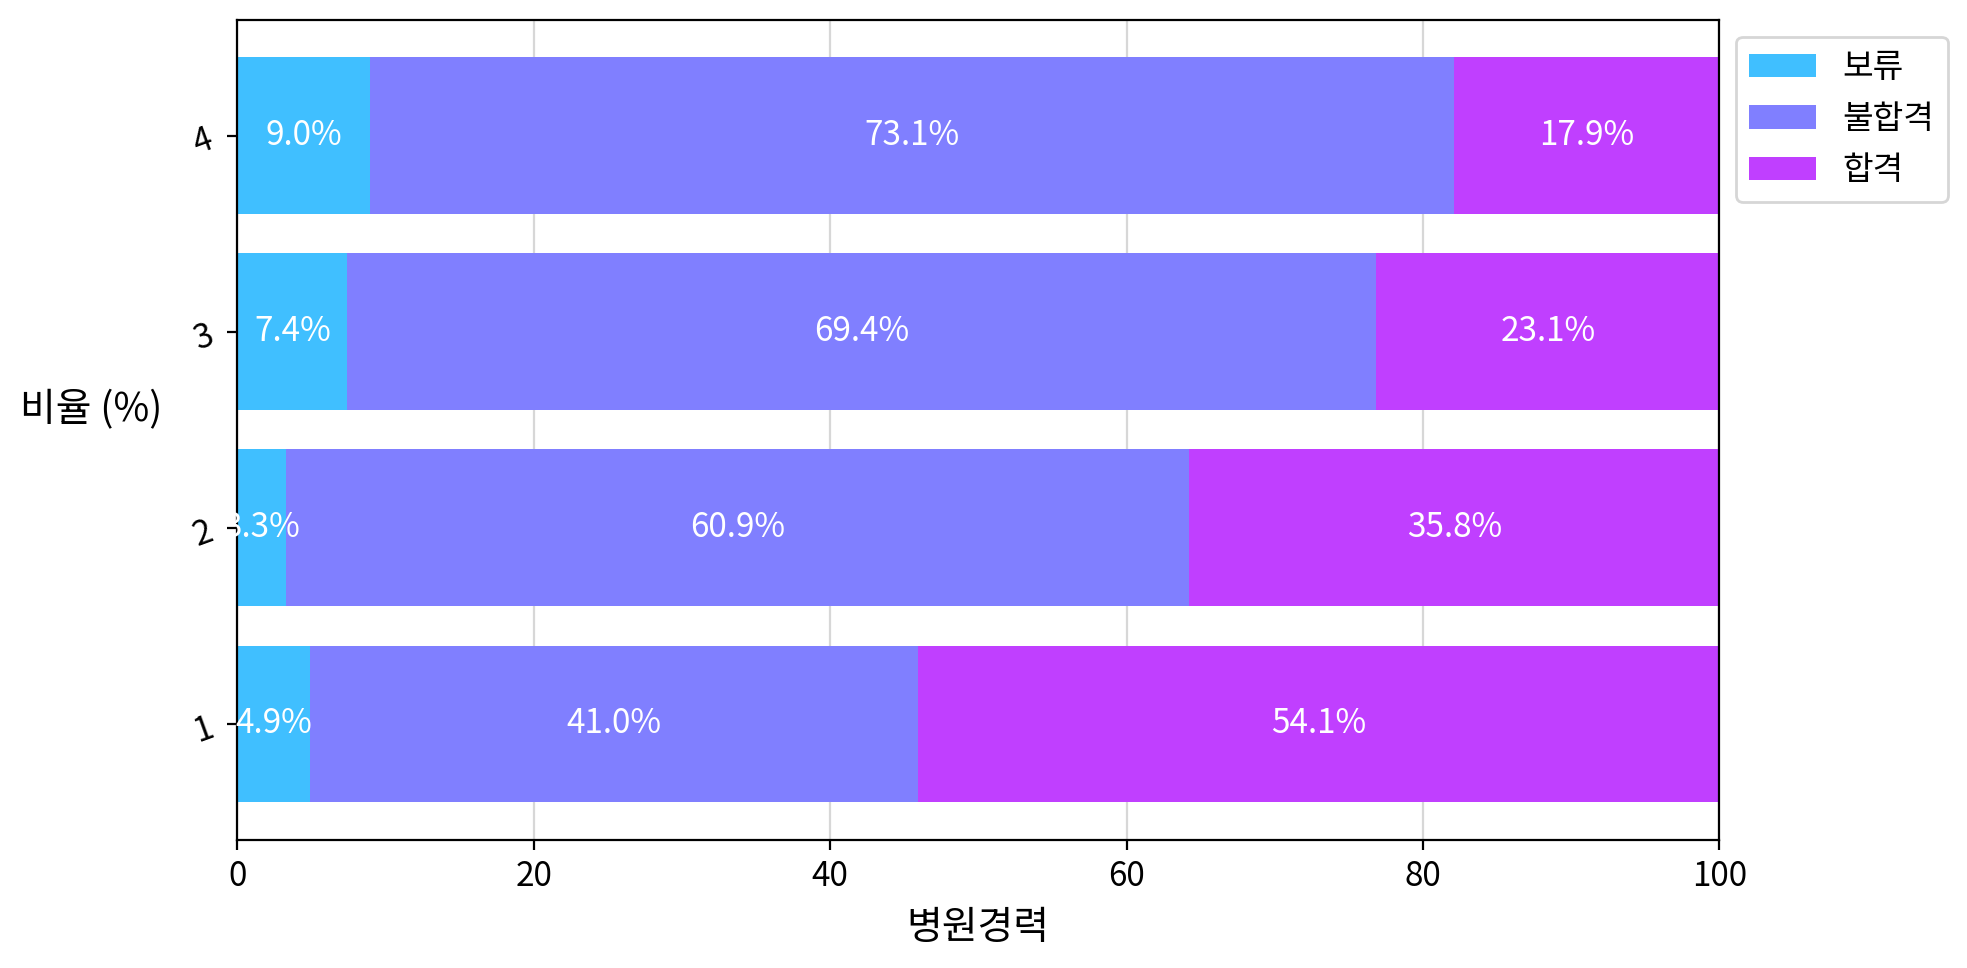

,,검정 방식,통계량 결과,자유도 결과,p값 결과,귀무가설 기각 여부,유의미한 차이 여부,효과 크기,효과 크기 (설명),기대값 최소,가설 검정 만족 여부
행,열,,,,,,,,,,
병원경력,합격여부,카이제곱 테스트 of homogeneity,27.378,6,0.000,True,True,0.185,약함,3.510,True


합격여부,보류,불합격,합격,전체 합계 (개수)
병원경력,,,,
1,0.049,0.410,0.541,61
2,0.033,0.609,0.358,151
3,0.074,0.694,0.231,121
4,0.090,0.731,0.179,67


y축 세우기 (단일 플롯)
그래프를 그렸습니다


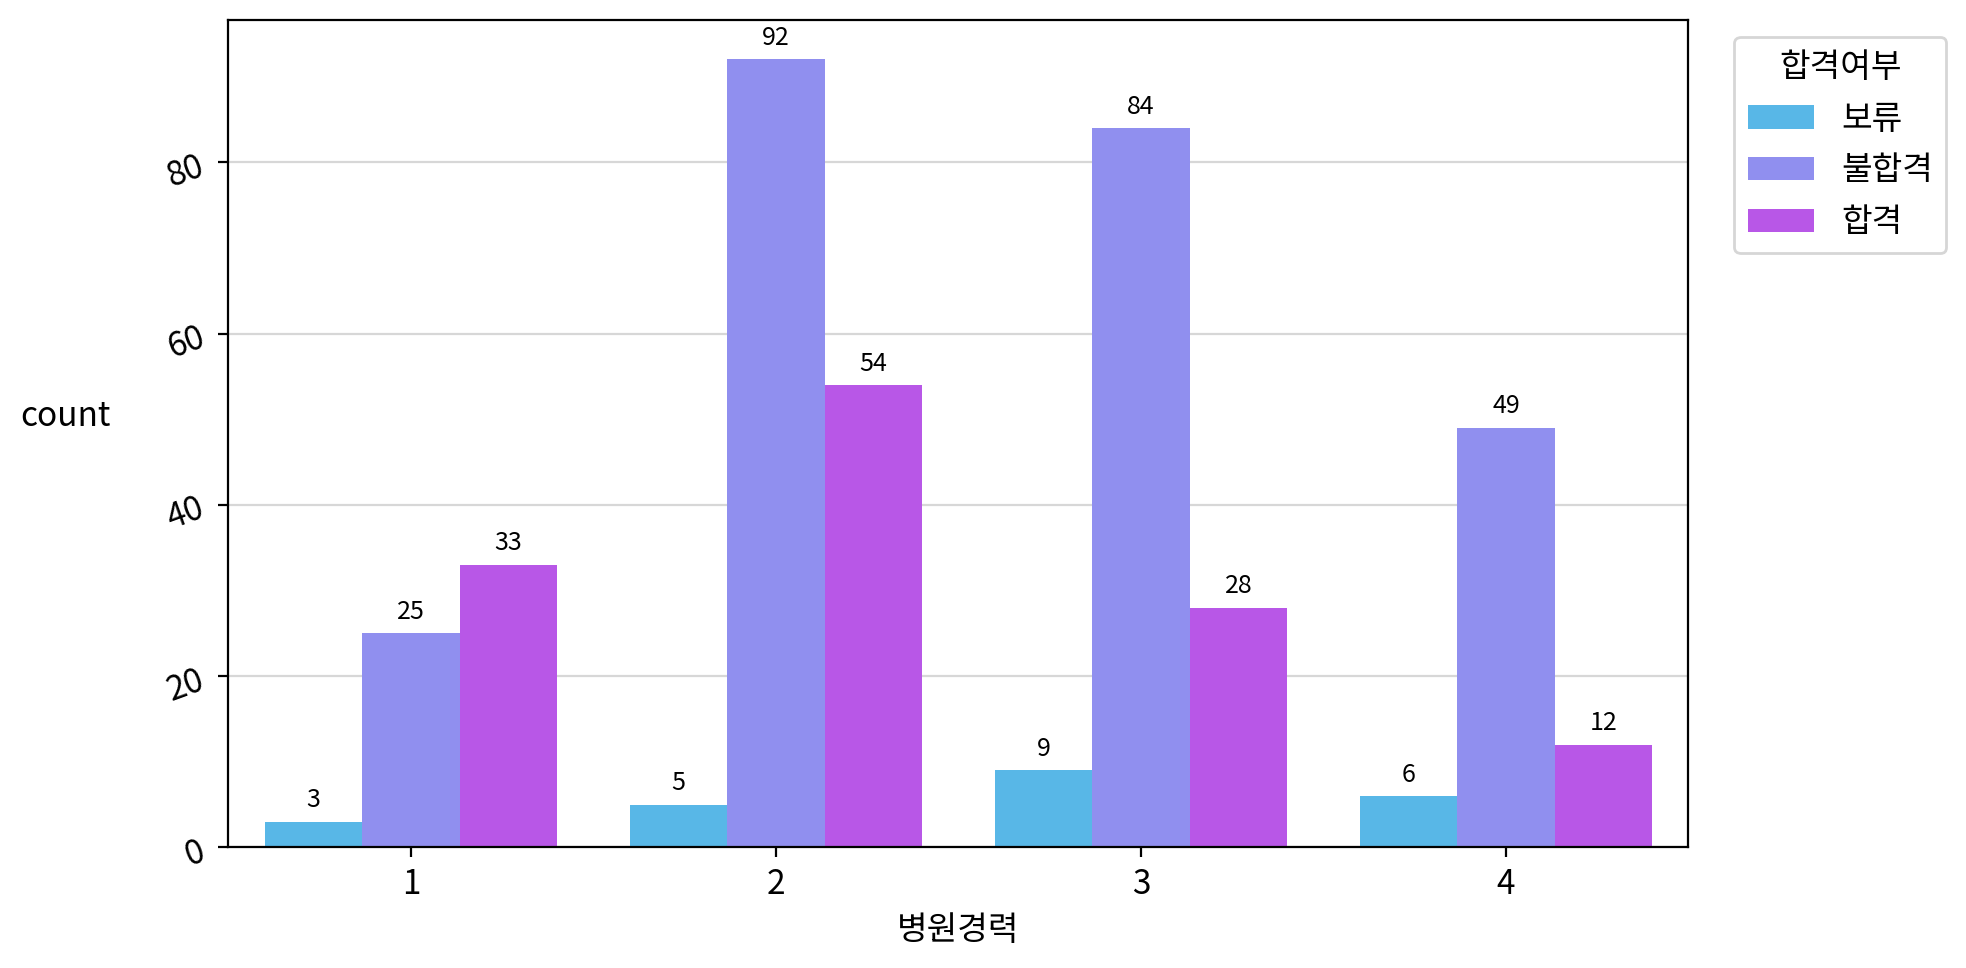

In [26]:
적합도_검정결과 , 카이제곱_결과 , 비율부분_결과 = my_EDA.카이제곱_교차분석(카테고리_변환 = 카테고리_변환 , 종속변수 = 종속변수 , 표시옵션 = 1)

In [27]:
적합도_검정결과

,통계량,자유도,p 값,귀무가설 기각 여부,유의미한 차이 여부,효과 크기,효과 크기 (설명),기대값 최소,가정 확인,검정 방식
카이제곱 적합도 검정,193.685,2,0.000,True,True,0.696,강함,133.330,True,카이제곱 적합도 검정


In [28]:
카이제곱_결과

,,검정 방식,통계량 결과,자유도 결과,p값 결과,귀무가설 기각 여부,유의미한 차이 여부,효과 크기,효과 크기 (설명),기대값 최소,가설 검정 만족 여부
행,열,,,,,,,,,,
성별,합격여부,카이제곱 테스트 of homogeneity,0.941,2,0.625,False,False,0.049,거의 없음,11.150,True
병원경력,합격여부,카이제곱 테스트 of homogeneity,27.378,6,0.000,True,True,0.185,약함,3.510,True


In [29]:
비율부분_결과

합격여부,보류,불합격,합격,전체 합계 (개수)
남,0.046,0.639,0.314,194
여,0.068,0.612,0.320,206
1,0.049,0.410,0.541,61
2,0.033,0.609,0.358,151
3,0.074,0.694,0.231,121
4,0.090,0.731,0.179,67


합격여부
보류      23
불합격    250
합격     127
Name: count, dtype: int64

관측 합계는 400
관측 개수는 3
실질적인 기대값은 [133.3333 133.3333 133.3333]
전체 칸 수   : 3
기대 빈도 5 미만 칸 수 : 0
기대 빈도 5 이상 비율 : 100%
최소 기대 빈도 : 133.3
통계량 : 193.685  /  p 값은 0.0000
효과 크기는 0.6958537921144068
실제 강도는 강함


,통계량,자유도,p 값,귀무가설 기각 여부,유의미한 차이 여부,효과 크기,효과 크기 (설명),기대값 최소,가정 확인,검정 방식
카이제곱 적합도 검정,193.685,2,0.000,True,True,0.696,강함,133.330,True,카이제곱 적합도 검정


y축 세우기 (단일 플롯)
기본은 평균 값을 구하게 됩니다
그래프를 그렸습니다


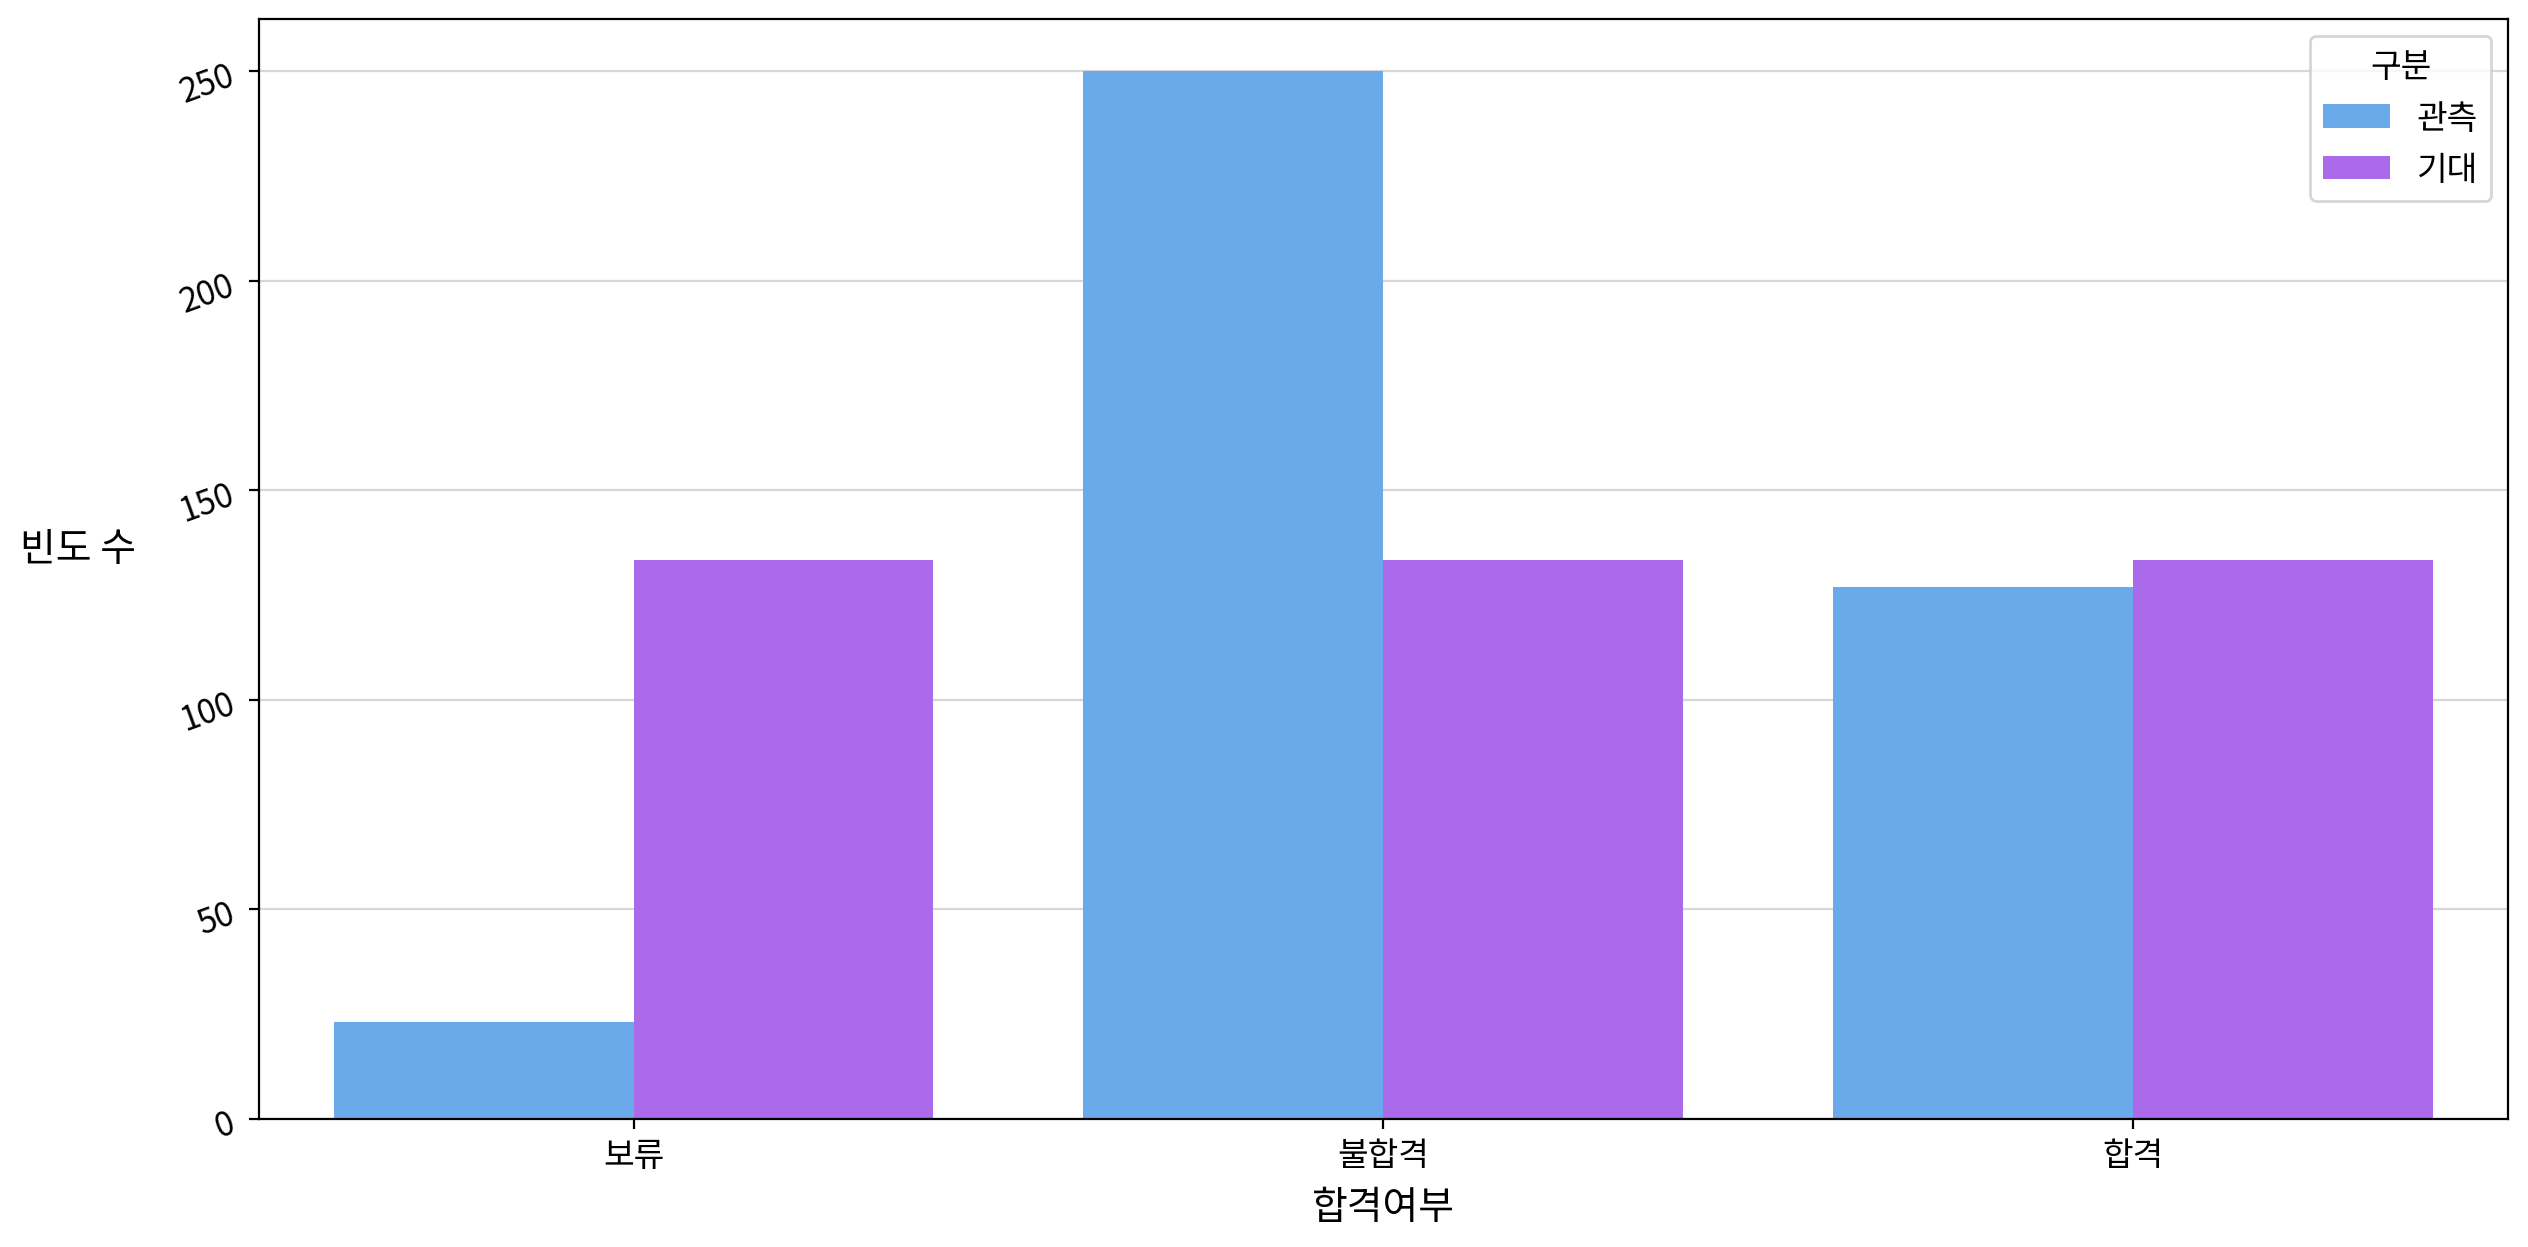

y축 세우기 (단일 플롯)
합계를 기준으로 피벗 테이블이 만들어지고 요약 될 예정
색상이 채워집니다
그래프를 그렸습니다


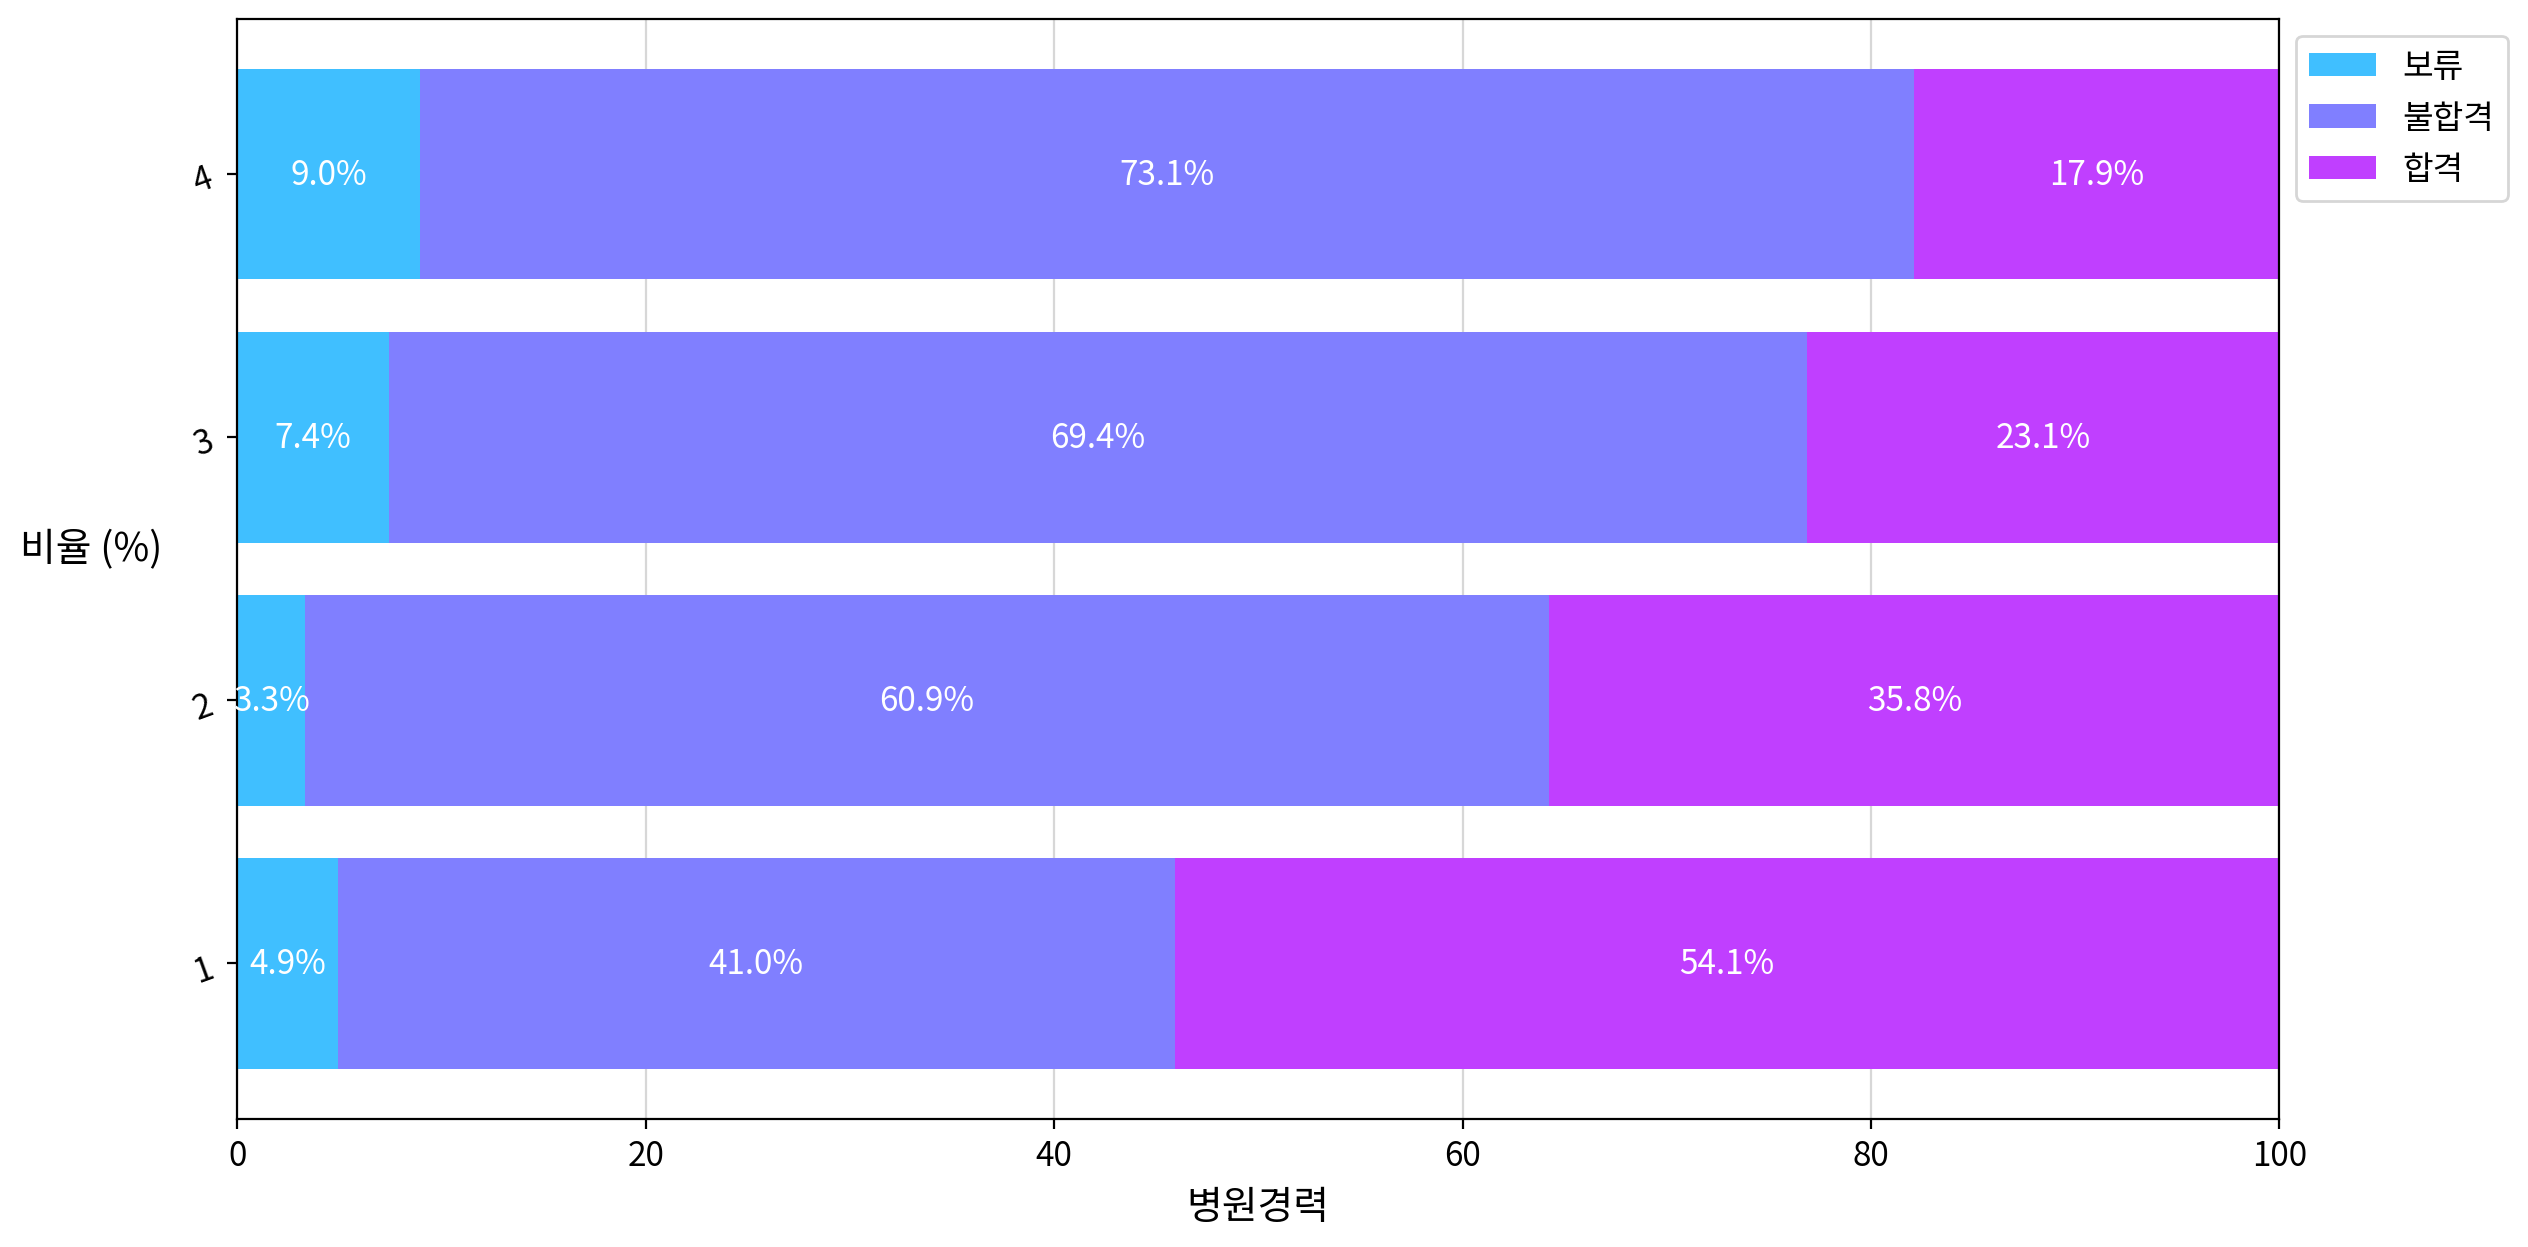

y축 세우기 (단일 플롯)
합계를 기준으로 피벗 테이블이 만들어지고 요약 될 예정
색상이 채워집니다
그래프를 그렸습니다


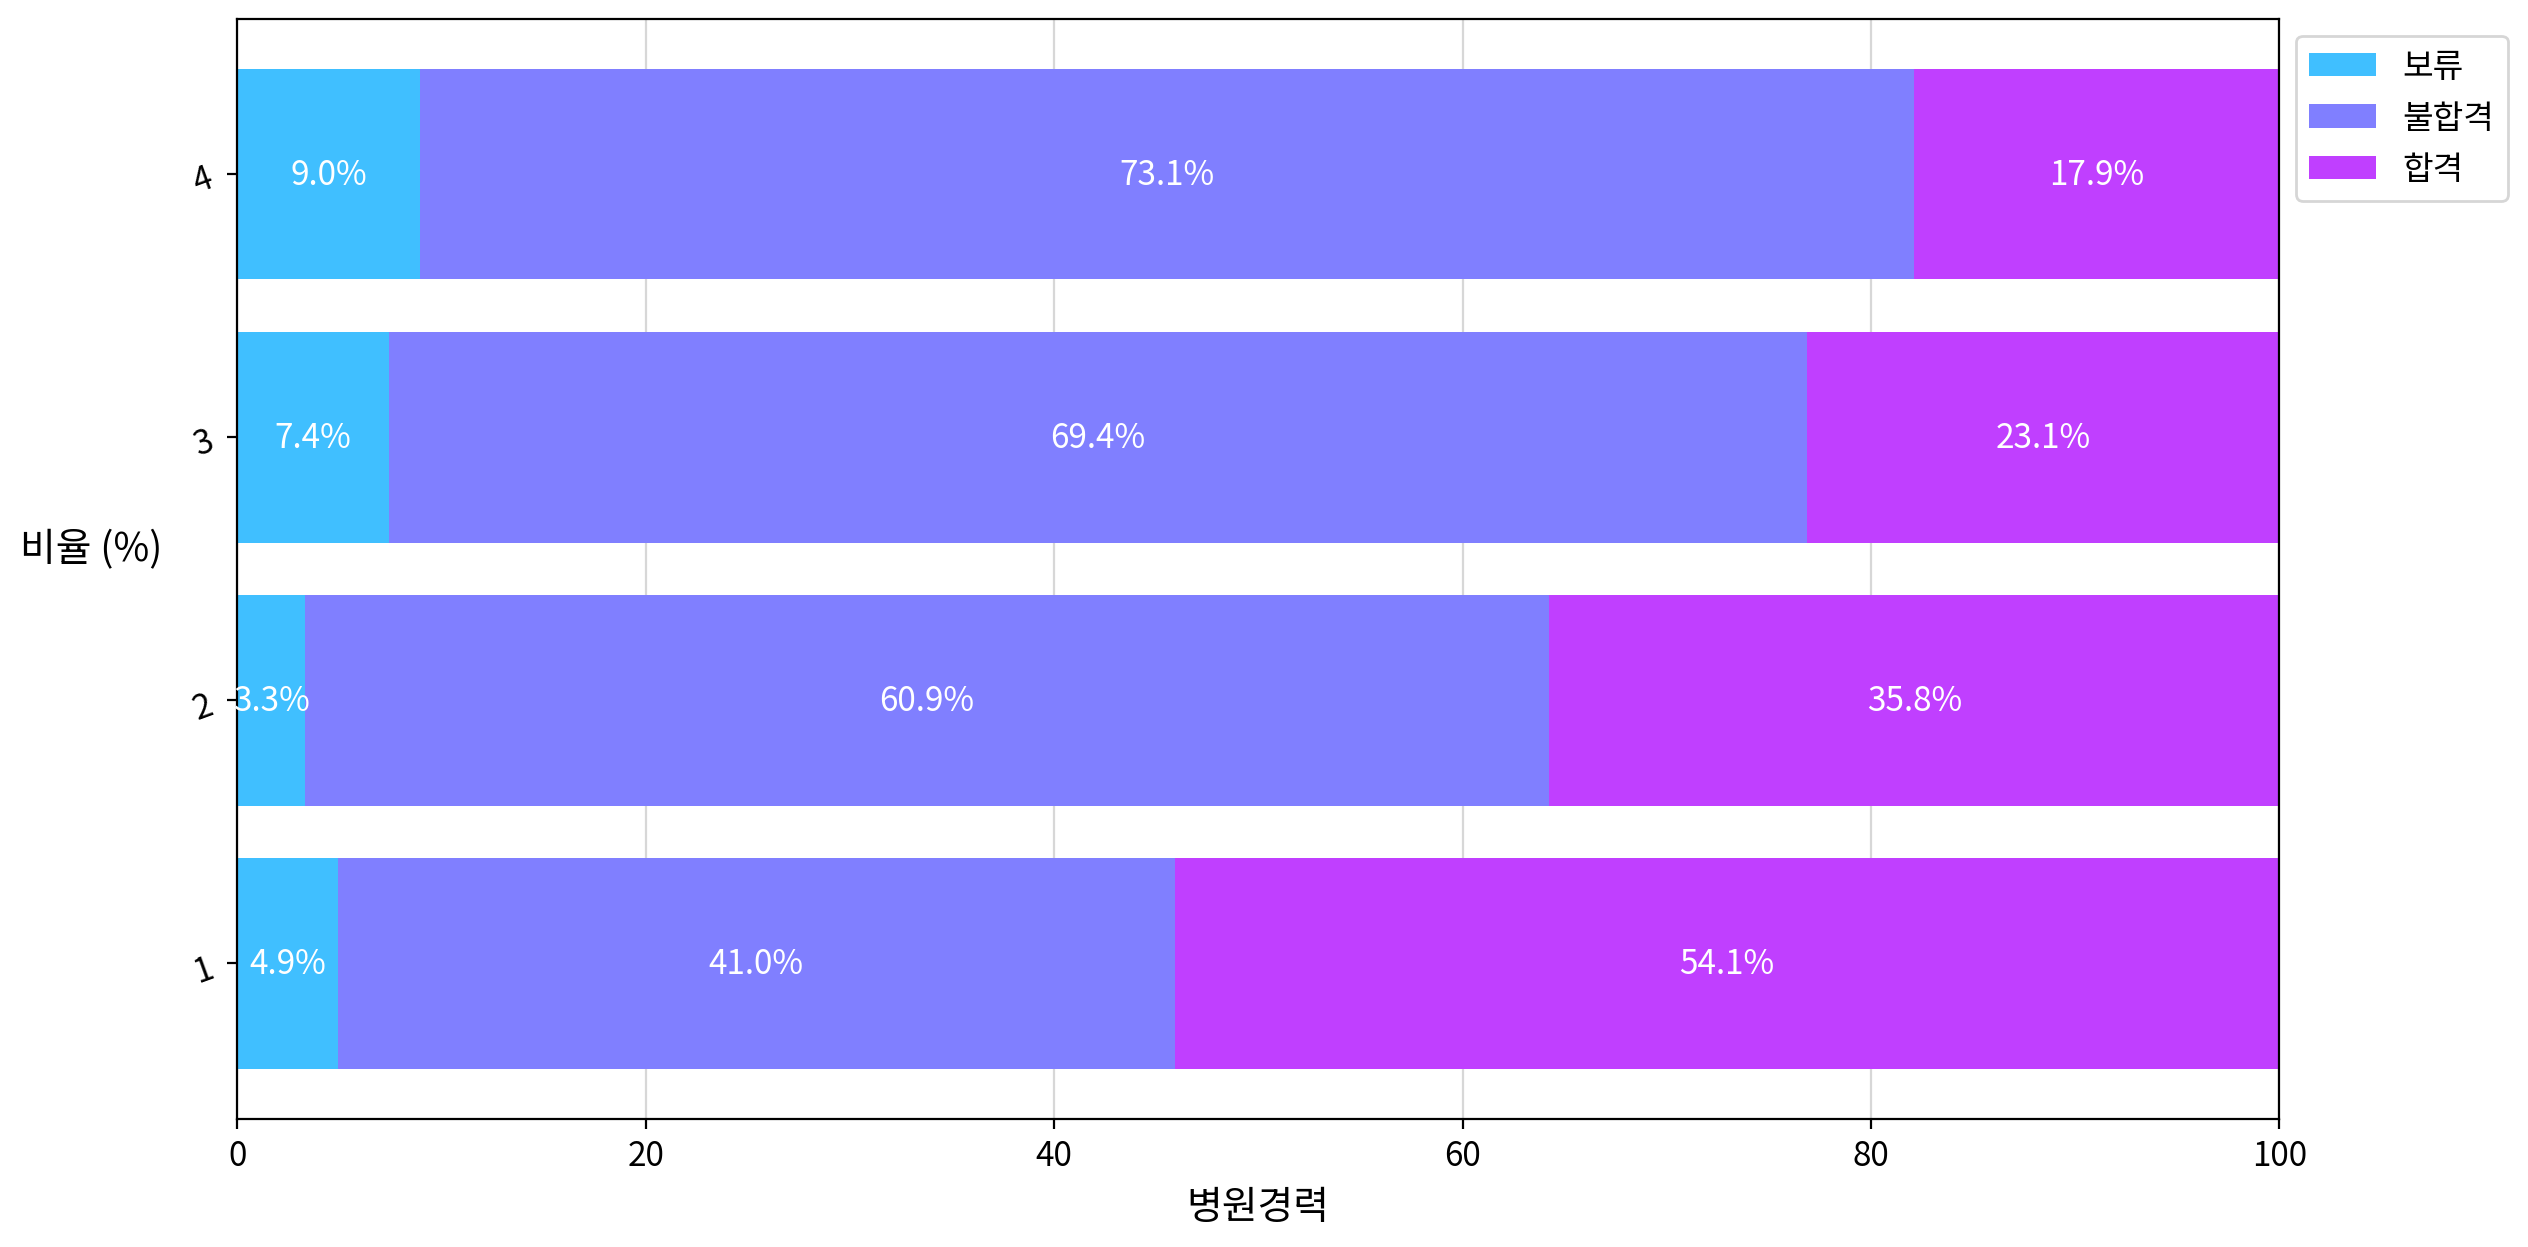

,,검정 방식,통계량 결과,자유도 결과,p값 결과,귀무가설 기각 여부,유의미한 차이 여부,효과 크기,효과 크기 (설명),기대값 최소,가설 검정 만족 여부
행,열,,,,,,,,,,
병원경력,합격여부,카이제곱 테스트 of independence,27.378,6,0.000,True,True,0.185,약함,3.510,True


,,검정 방식,통계량 결과,자유도 결과,p값 결과,귀무가설 기각 여부,유의미한 차이 여부,효과 크기,효과 크기 (설명),기대값 최소,가설 검정 만족 여부
행,열,,,,,,,,,,
병원경력,합격여부,카이제곱 테스트 of homogeneity,27.378,6,0.000,True,True,0.185,약함,3.510,True


In [30]:
my_stats.카이제곱_적합도_검정(대상 = 카테고리_변환 , 칼럼 = 종속변수)

# 종속변수 범주에 도메인이 2 개
독립성결과 = my_stats.카이제곱_독립성_검정(대상 = 카테고리_변환 , x = '병원경력' , y = 종속변수 , orient='h',
                             표시옵션 = 0)

# 종속변수 범주에 도메인이 3 개 이상
동질성결과 = my_stats.카이제곱_동질성_검정(대상 = 카테고리_변환 , 그룹 = '병원경력' , 카테고리 = 종속변수 , orient='h' , 
                             표시옵션 = 0)

display(독립성결과 , 동질성결과)